In [2]:
# Cell 1: Imports & Setup
%matplotlib inline
import MDAnalysis as mda
from MDAnalysis.lib.distances import distance_array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import itertools
from scipy.spatial.distance import cdist
from IPython.display import display, Image # 用于在笔记中显示生成的图片

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Cell 2: Global Configuration

# === T-Stacking 判定参数 ===
T_STACK_DIST_CUTOFF = 6.5 
T_STACK_ANGLE_CENTER = 90.0
T_STACK_ANGLE_TOL = 30.0 

# === 关键残基定义 (标准编号) ===
PHE_RESIDUES = [389, 390] # 6.51, 6.52
OBP_RESIDUES = [114, 115, 118, 119, 190, 193, 194, 197, 386, 393, 412, 416]
PLANE_RESIDUES = [198, 163, 76, 127]

# === 计算参数 ===
INTEGRATION_RADIUS = 1.5 
BOHR_TO_ANGSTROM = 0.52917721067

# === 化合物特殊设置 ===
OFFSET_CONFIG = {"unc": -29}
DEFAULT_OFFSET = 0

# 手动白名单 (跳过自动匹配，强制指定原子)
# 格式: "化合物关键词": ["原子名1", "原子名2", ...]
MANUAL_ATOM_OVERRIDES = {
    "unc": ['C16', 'C13', 'C8', 'C7', 'C12', 'C15']
}

# 全局变量 (运行时自动计算)
GLOBAL_DOPA_MAX_INTEGRAL = 1.0 

print("Configuration loaded.")

Configuration loaded.


In [4]:
# Cell 3: Core Classes

# --- 1. CUBE 解析器 ---
class CubeParser:
    def __init__(self, filepath):
        self.filepath = filepath
        self.data = None; self.origin = None; self.spacing = None; self.dims = None
        self.atom_lines = []; self.is_header_bohr = True 
        self._load()

    def _load(self):
        try:
            with open(self.filepath, 'r') as f:
                lines = f.readlines()
                parts = lines[2].split()
                natoms = int(parts[0])
                if natoms > 0: self.is_header_bohr = True
                else: self.is_header_bohr = False; natoms = abs(natoms)
                
                self.origin = np.array([float(x) for x in parts[1:4]])
                nx = int(lines[3].split()[0]); vx = np.array([float(x) for x in lines[3].split()[1:4]])
                ny = int(lines[4].split()[0]); vy = np.array([float(x) for x in lines[4].split()[1:4]])
                nz = int(lines[5].split()[0]); vz = np.array([float(x) for x in lines[5].split()[1:4]])
                self.dims = (nx, ny, nz); self.spacing = np.array([vx[0], vy[1], vz[2]]) 
                
                self.atom_lines = lines[6 : 6 + natoms]
                data_start = 6 + natoms
                raw_data = []
                for line in lines[data_start:]: raw_data.extend([float(x) for x in line.split()])
                self.data = np.array(raw_data).reshape(self.dims)
        except Exception as e:
            print(f"     [Cube Error] {e}"); self.data = None

    def get_carbon_integrals(self, radius=1.5):
        if self.data is None: return np.array([])
        origin_ang = self.origin * BOHR_TO_ANGSTROM
        spacing_ang = self.spacing * BOHR_TO_ANGSTROM
        integrals = []
        nx, ny, nz = self.dims
        
        for line in self.atom_lines:
            parts = line.split()
            if int(parts[0]) == 6: # Carbon
                raw_coord = np.array([float(x) for x in parts[2:5]])
                atom_coord_ang = raw_coord * BOHR_TO_ANGSTROM if self.is_header_bohr else raw_coord
                
                min_coord = atom_coord_ang - radius
                max_coord = atom_coord_ang + radius
                min_idx = np.maximum(np.floor((min_coord - origin_ang) / spacing_ang).astype(int), 0)
                max_idx = np.minimum(np.ceil((max_coord - origin_ang) / spacing_ang).astype(int) + 1, [nx, ny, nz])
                
                if np.any(min_idx >= max_idx):
                    integrals.append(0.0); continue
                
                local_data = self.data[min_idx[0]:max_idx[0], min_idx[1]:max_idx[1], min_idx[2]:max_idx[2]]
                ix = np.arange(min_idx[0], max_idx[0]); iy = np.arange(min_idx[1], max_idx[1]); iz = np.arange(min_idx[2], max_idx[2])
                X, Y, Z = np.meshgrid(ix, iy, iz, indexing='ij')
                
                grid_pos_x = origin_ang[0] + X * spacing_ang[0]
                grid_pos_y = origin_ang[1] + Y * spacing_ang[1]
                grid_pos_z = origin_ang[2] + Z * spacing_ang[2]
                dist_sq = (grid_pos_x - atom_coord_ang[0])**2 + (grid_pos_y - atom_coord_ang[1])**2 + (grid_pos_z - atom_coord_ang[2])**2
                mask = dist_sq < (radius**2)
                integrals.append(np.sum(local_data[mask]))
        return np.array(integrals)

# --- 2. 几何匹配器 (Soft Match V9) ---
class RingMatcher:
    def __init__(self, ref_coords, ref_elements):
        self.ref_coords = ref_coords
        self.ref_elements = ref_elements
        self.n_ref = len(ref_coords)
        self.ref_ring_idx = self._find_single_ring(ref_coords, ref_elements)
        if self.ref_ring_idx is None:
            c_indices = [i for i, e in enumerate(ref_elements) if e == 'C']
            if len(c_indices) == 6: self.ref_ring_idx = c_indices
            else: raise ValueError(f"No 6-ring found in ref")
        self.ref_neigh_idx = []
        dmat = cdist(ref_coords, ref_coords)
        ring_set = set(self.ref_ring_idx)
        for i in range(self.n_ref):
            if i in ring_set: continue
            if np.min(dmat[i, self.ref_ring_idx]) < 1.70: # 放宽到 1.70
                self.ref_neigh_idx.append(i)

    def _find_single_ring(self, coords, elements):
        c_indices = [i for i, e in enumerate(elements) if e == 'C']
        if len(c_indices) < 6: return None
        sub_coords = coords[c_indices]
        dmat = cdist(sub_coords, sub_coords)
        adj = np.logical_and(dmat > 1.1, dmat < 1.65) # 放宽到 1.65
        for comb in itertools.combinations(range(len(c_indices)), 6):
            sub_idx = list(comb); curr_coords = sub_coords[sub_idx]
            if np.linalg.svd(curr_coords - curr_coords.mean(0))[1][2] > 0.3: continue 
            sub_adj = adj[np.ix_(sub_idx, sub_idx)]
            if np.all(np.sum(sub_adj, axis=1) >= 2):
                local_ordered = self._order_ring_indices(sub_idx, sub_adj)
                return [c_indices[i] for i in local_ordered]
        return None

    def _order_ring_indices(self, indices, sub_adj):
        ordered = [indices[0]]; current = 0; used = {0}
        for _ in range(5):
            for n in np.where(sub_adj[current])[0]:
                if n not in used: ordered.append(indices[n]); used.add(n); current = n; break
        return ordered

    def match(self, md_atoms, anchor_com):
        md_coords = md_atoms.positions
        md_c_indices = [i for i, a in enumerate(md_atoms) if a.name.startswith('C')]
        if len(md_c_indices) < 6: return None, None
        md_c_coords = md_coords[md_c_indices]
        dmat = cdist(md_c_coords, md_c_coords)
        adj = np.logical_and(dmat > 1.1, dmat < 1.70) # 放宽到 1.70
        
        found_rings_local = []
        seen = set()
        for i in range(len(md_c_indices)):
            res = self._dfs(i, i, adj, [i])
            if res:
                s = tuple(sorted(res))
                if s not in seen: found_rings_local.append(list(res)); seen.add(s)
        
        if not found_rings_local: return None, None
        
        best_ring_global_idx = None
        min_dist = float('inf')
        for local_ring in found_rings_local:
            global_ring = [md_c_indices[i] for i in local_ring]
            ring_center = md_coords[global_ring].mean(axis=0)
            d = np.linalg.norm(ring_center - anchor_com) 
            if d < min_dist: min_dist = d; best_ring_global_idx = global_ring
        
        ref_ring_c = self.ref_coords[self.ref_ring_idx]
        md_ring_c = md_coords[best_ring_global_idx]
        ref_neigh_c = self.ref_coords[self.ref_neigh_idx] if self.ref_neigh_idx else None
        
        best_perm = None
        min_neighbor_dist = float('inf')
        
        base = list(range(6))
        shifts = [base[i:] + base[:i] for i in range(6)]
        perms = shifts + [s[::-1] for s in shifts]
        
        for p in perms:
            target = md_ring_c[list(p)]
            R, t = self._get_transform(ref_ring_c, target)
            
            # Rigid check
            ring_rms = np.mean(np.linalg.norm((np.dot(ref_ring_c, R.T)+t) - target, axis=1))
            if ring_rms > 0.5: continue
            
            # Soft check
            curr_score = ring_rms
            if ref_neigh_c is not None:
                trans_neigh = np.dot(ref_neigh_c, R.T) + t
                dmat_check = cdist(trans_neigh, md_coords)
                curr_score = np.mean(np.min(dmat_check, axis=1))
            
            if curr_score < min_neighbor_dist:
                min_neighbor_dist = curr_score
                best_perm = p

        if best_perm is None: return None, None
        matched_md_atoms = md_atoms[[best_ring_global_idx[i] for i in best_perm]]
        ref_c_indices = [i for i, e in enumerate(self.ref_elements) if e == 'C']
        global_to_carbon_rank = {idx: rank for rank, idx in enumerate(ref_c_indices)}
        cube_indices = [global_to_carbon_rank[idx] for idx in self.ref_ring_idx]
        return matched_md_atoms, cube_indices

    def _dfs(self, start, curr, adj, path):
        if len(path) == 6: return path if adj[curr, start] else None
        for n in np.where(adj[curr])[0]:
            if n == start and len(path) < 5: continue
            if n not in path:
                res = self._dfs(start, n, adj, path + [n])
                if res: return res
        return None

    def _get_transform(self, P, Q):
        Pc = P.mean(axis=0); Qc = Q.mean(axis=0)
        H = np.dot((P-Pc).T, (Q-Qc))
        U, S, Vt = np.linalg.svd(H); R = np.dot(Vt.T, U.T)
        if np.linalg.det(R) < 0: Vt[2,:] *= -1; R = np.dot(Vt.T, U.T)
        return R, Qc - np.dot(Pc, R.T)
        
print("Core classes initialized.")

Core classes initialized.


In [5]:
# Cell 4: Helper Functions

def get_ref_data_from_pdb(pdb_file):
    coords = []; elements = []
    try:
        with open(pdb_file, 'r') as f:
            for line in f:
                if (line.startswith("ATOM") or line.startswith("HETATM")):
                    name = line[12:16].strip()
                    if name.upper().startswith("CL") or name.upper().startswith("CA"): continue
                    elem = name[0]
                    coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
                    elements.append(elem)
    except: return None, None
    if len(coords) > 100: return None, None
    return np.array(coords), elements

def calculate_plane_normal(coords):
    c = coords - coords.mean(axis=0)
    return np.linalg.svd(c)[2][2,:]

def get_offset(cid):
    for k, v in OFFSET_CONFIG.items():
        if k in cid.lower(): return v
    return DEFAULT_OFFSET

def get_dopa_max_integral(root_dir):
    print(">>> 1. Pre-scanning for Dopa Global Max Integral...")
    max_val = 1.0; found = False
    for c_dir in glob.glob(os.path.join(root_dir, "*")):
        if not os.path.isdir(c_dir): continue
        if "dopa" in os.path.basename(c_dir).lower():
            cubes = glob.glob(os.path.join(c_dir, "*.cub"))
            if cubes:
                print(f"    Checking Dopa CUBE: {cubes[0]}")
                cp = CubeParser(cubes[0])
                integrals = cp.get_carbon_integrals(radius=INTEGRATION_RADIUS)
                if len(integrals) > 0:
                    max_val = np.max(integrals); found = True
                    print(f"    [GLOBAL STD] Dopa Max = {max_val:.2f}")
            else:
                print(f"    [Warn] Dopa folder {c_dir} has NO .cub file.")
            break
    if not found: print("    [WARN] Dopa not found! Using Max=1.0.")
    return max_val

def align_to_xy_plane(ligand_pos, obp_pos_list, whole_ligand_pos):
    center = ligand_pos.mean(axis=0)
    lig_centered = ligand_pos - center
    obp_centered = obp_pos_list - center
    whole_centered = whole_ligand_pos - center
    u, s, vh = np.linalg.svd(lig_centered)
    lig_xy = np.dot(lig_centered, vh.T)[:, :2]
    obp_xy = np.dot(obp_centered, vh.T)[:, :2]
    whole_xy = np.dot(whole_centered, vh.T)[:, :2]
    return lig_xy, obp_xy, whole_xy

def plot_projection(lig_xy, obp_xy, whole_xy, elf_weights, obp_labels, output_file, compound_id):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    ax.scatter(whole_xy[:,0], whole_xy[:,1], c='lightgray', s=30, label='Ligand Body', zorder=1)
    sc = ax.scatter(lig_xy[:,0], lig_xy[:,1], c=elf_weights, cmap='coolwarm', 
                    vmin=0, vmax=1.0, s=500, edgecolors='k', zorder=2, label='Target Ring')
    loop = np.vstack([lig_xy, lig_xy[0]])
    ax.plot(loop[:,0], loop[:,1], 'k-', lw=2, zorder=2)
    for i, (x, y) in enumerate(lig_xy):
        ax.text(x, y, f"{elf_weights[i]:.2f}", ha='center', va='center', color='white', fontweight='bold', fontsize=9, zorder=3)
    for i, (x, y) in enumerate(obp_xy):
        label = obp_labels[i]
        color = 'red' if label in ['389', '390'] else 'blue'
        size = 150 if label in ['389', '390'] else 80
        marker = '^' if label in ['389', '390'] else 'o'
        ax.scatter(x, y, c=color, marker=marker, s=size, alpha=0.7, edgecolors='none', zorder=1)
        ax.text(x+0.2, y+0.2, label, color=color, fontsize=10)
    plt.colorbar(sc, label='Norm. ELF Integral', fraction=0.046, pad=0.04)
    plt.title(f"Ligand-OBP Projection (XY Plane)\nCompound: {compound_id}")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlabel("Projected X (A)"); plt.ylabel("Projected Y (A)")
    
    print(f"  -> Saving plot to {output_file}")
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close() # 必须关闭，否则内存爆炸

def find_ligand_residue(u):
    """鲁棒的配体搜索逻辑"""
    priority = u.select_atoms("resname LIG LIG1 LDP R5F DRG UNK")
    if len(priority) > 0: return priority.residues[0]
    blacklist = ["TIP3","TIP4","SOL","WAT","SOD","CLA","POT","CAL","ZN","MG",
                 "POPC","POPE","CHL","CHOL","ALA","ARG","ASN","ASP","CYS","GLN",
                 "GLU","GLY","HIS","ILE","LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL"]
    candidates = []
    for r in u.residues:
        if r.resname in blacklist: continue
        if len(r.atoms) < 3: continue
        candidates.append(r)
    if not candidates: return None
    candidates.sort(key=lambda r: len(r.atoms), reverse=True)
    return candidates[0]

print("Helper functions defined.")

Helper functions defined.


In [6]:
# Cell 5: Main Process Logic

def process_trajectory(xtc_files, topo, cube, ref_pdb, cid):
    print(f"  Processing {len(xtc_files)} files as one continuous replicate...")
    
    ref_coords, ref_elements = get_ref_data_from_pdb(ref_pdb)
    if ref_coords is None: 
        print(f"     [Error] Ref PDB invalid: {os.path.basename(ref_pdb)}"); return None
    
    cp = CubeParser(cube)
    raw_integrals = cp.get_carbon_integrals(radius=INTEGRATION_RADIUS)
    n_c_pdb = ref_elements.count('C')
    if n_c_pdb != len(raw_integrals):
        print(f"     [Error] Size Mismatch: PDB({n_c_pdb}) vs CUBE({len(raw_integrals)})"); return None

    try: u = mda.Universe(topo, xtc_files)
    except Exception as e: 
        print(f"     [Error] MD Load failed: {e}"); return None

    lig_res = find_ligand_residue(u)
    if lig_res is None:
        print("     [Error] Could not identify ligand residue."); return None
        
    print(f"     [Info] Identified Ligand: {lig_res.resname} (ID {lig_res.resid}) with {len(lig_res.atoms)} atoms")
    ligand_all = lig_res.atoms

    manual_atoms = None
    for k, v in MANUAL_ATOM_OVERRIDES.items():
        if k in cid.lower(): manual_atoms = v; break

    matched_ring = None; elf_weights = None
    offset = get_offset(cid)
    
    phe_ring_names = ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"]
    res_389 = u.select_atoms(f"resid {389+offset}")
    res_390 = u.select_atoms(f"resid {390+offset}")
    phe_389_ring = res_389.select_atoms(f"name {' '.join(phe_ring_names)}")
    phe_390_ring = res_390.select_atoms(f"name {' '.join(phe_ring_names)}")
    
    if len(phe_389_ring) == 6: anchor_com = phe_389_ring.center_of_mass()
    elif len(res_389) > 0: anchor_com = res_389.atoms.center_of_mass()
    else: 
        print(f"     [Error] Anchor resid 389 not found"); return None

    if manual_atoms:
        matched_ring = lig_res.atoms.select_atoms(f"name {' '.join(manual_atoms)}")
        if len(matched_ring) == 6:
            try:
                rm = RingMatcher(ref_coords, ref_elements)
                matched_ring, cube_idx = rm.match(matched_ring, anchor_com)
                if matched_ring:
                    elf_weights = raw_integrals[cube_idx] / GLOBAL_DOPA_MAX_INTEGRAL
            except: pass
    else:
        cands = lig_res.atoms.select_atoms("name C*")
        if len(cands) > 5:
            try:
                rm = RingMatcher(ref_coords, ref_elements)
                matched_ring, cube_idx = rm.match(cands, anchor_com)
                if matched_ring:
                    elf_weights = raw_integrals[cube_idx] / GLOBAL_DOPA_MAX_INTEGRAL
            except: pass

    if matched_ring is None: 
        print(f"     [Error] Ring not found in residue {lig_res.resname}"); return None

    print(f"     [Match] Norm ELF: {np.min(elf_weights):.2f}-{np.max(elf_weights):.2f}")

    obp_atoms = u.select_atoms(f"resid {' '.join(map(str, [x+offset for x in OBP_RESIDUES]))} and name CA")
    plane_res = u.select_atoms(f"resid {' '.join(map(str, [x+offset for x in PLANE_RESIDUES]))} and name CA")
    if len(plane_res) == 0: 
        print(f"     [Error] Plane residues not found"); return None
        
    frame_data = []
    vis_obp_accum = np.zeros((len(OBP_RESIDUES)+2, 2))
    vis_count = 0
    vis_labels = [str(r) for r in OBP_RESIDUES] + ["389(Phe)", "390(Phe)"]

    for ts in u.trajectory:
        lig_pos = matched_ring.positions
        lig_center = lig_pos.mean(axis=0)
        lig_normal = calculate_plane_normal(lig_pos)
        plane_normal = calculate_plane_normal(plane_res.positions)
        
        global_angle = np.degrees(np.arccos(np.clip(np.dot(lig_normal, plane_normal), -1, 1)))
        if global_angle > 90: global_angle = 180 - global_angle
        
        is_active_frame = False
        
        if len(phe_389_ring) == 6:
            phe_c = phe_389_ring.positions.mean(axis=0)
            phe_n = calculate_plane_normal(phe_389_ring.positions)
            d = np.linalg.norm(lig_center - phe_c)
            ang = np.degrees(np.arccos(np.clip(np.dot(lig_normal, phe_n), -1, 1)))
            if d < T_STACK_DIST_CUTOFF:
                if abs(90 - ang) < T_STACK_ANGLE_TOL or abs(90 - (180-ang)) < T_STACK_ANGLE_TOL:
                    is_active_frame = True
        
        if not is_active_frame and len(phe_390_ring) == 6:
            phe_c = phe_390_ring.positions.mean(axis=0)
            phe_n = calculate_plane_normal(phe_390_ring.positions)
            d = np.linalg.norm(lig_center - phe_c)
            ang = np.degrees(np.arccos(np.clip(np.dot(lig_normal, phe_n), -1, 1)))
            if d < T_STACK_DIST_CUTOFF:
                if abs(90 - ang) < T_STACK_ANGLE_TOL or abs(90 - (180-ang)) < T_STACK_ANGLE_TOL:
                    is_active_frame = True

        t_stack_score = np.sum(elf_weights) if is_active_frame else 0.0
        d_obp = distance_array(lig_center[np.newaxis, :], obp_atoms.positions, box=u.dimensions)[0]
        
        target_positions = []
        for r_obj in obp_atoms: target_positions.append(r_obj.position)
        target_positions.append(phe_389_ring.positions.mean(axis=0) if len(phe_389_ring)==6 else np.array([0,0,0]))
        target_positions.append(phe_390_ring.positions.mean(axis=0) if len(phe_390_ring)==6 else np.array([0,0,0]))
        
        _, proj_xy, _ = align_to_xy_plane(lig_pos, np.array(target_positions), ligand_all.positions)
        vis_obp_accum += proj_xy; vis_count += 1

        row = {
            "Global_Angle": global_angle,
            "T_Stack_Score": t_stack_score,
            "Is_Active": 1 if is_active_frame else 0
        }
        for i, resid in enumerate(OBP_RESIDUES): row[f"Dist_Res_{resid}"] = d_obp[i]
        frame_data.append(row)

    df_frame = pd.DataFrame(frame_data)
    avg_occupancy = df_frame["Is_Active"].mean() * 100
    avg_angle = df_frame["Global_Angle"].mean()
    
    if vis_count > 0:
        avg_obp_xy = vis_obp_accum / vis_count
        lig_xy_final, _, whole_lig_xy = align_to_xy_plane(lig_pos, np.array([[0,0,0]]), ligand_all.positions)
        out_png = f"{cid}_{os.path.basename(os.path.dirname(xtc_files[0]))}_projection.png"
        plot_projection(lig_xy_final, avg_obp_xy, whole_lig_xy, elf_weights, vis_labels, out_png, cid)
        
        # [NEW] 在 Notebook 中展示生成的图片
        display(Image(out_png))

    output_row = {
        "Compound": cid,
        "Replica": os.path.basename(os.path.dirname(xtc_files[0])), 
        "ELF_T_Occupancy": avg_occupancy,
        "Global_Angle_Mean": avg_angle,
        "Global_Angle_SD": df_frame["Global_Angle"].std(),
    }
    for resid in OBP_RESIDUES: output_row[f"Dist_Res_{resid}"] = df_frame[f"Dist_Res_{resid}"].mean()
    for i, w in enumerate(elf_weights): output_row[f"C{i+1}_Weight"] = w
    return output_row

print("Logic loaded.")

Logic loaded.


>>> 1. Pre-scanning for Dopa Global Max Integral...
    Checking Dopa CUBE: ./20251115_D2_Dopa_cryoEM_rebuild/Dopa_ELF.cub
    [GLOBAL STD] Dopa Max = 2616.53

>>> Processing Trajectories... (Dopa Max = 2616.53)

Analyzing: 20251122_D2_S10_cryoEM_rebuild (3 replicates)
  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG (ID 1035) with 61 atoms
     [Match] Norm ELF: 0.29-0.85
  -> Saving plot to 20251122_D2_S10_cryoEM_rebuild_gromacs_replicate_2_projection.png


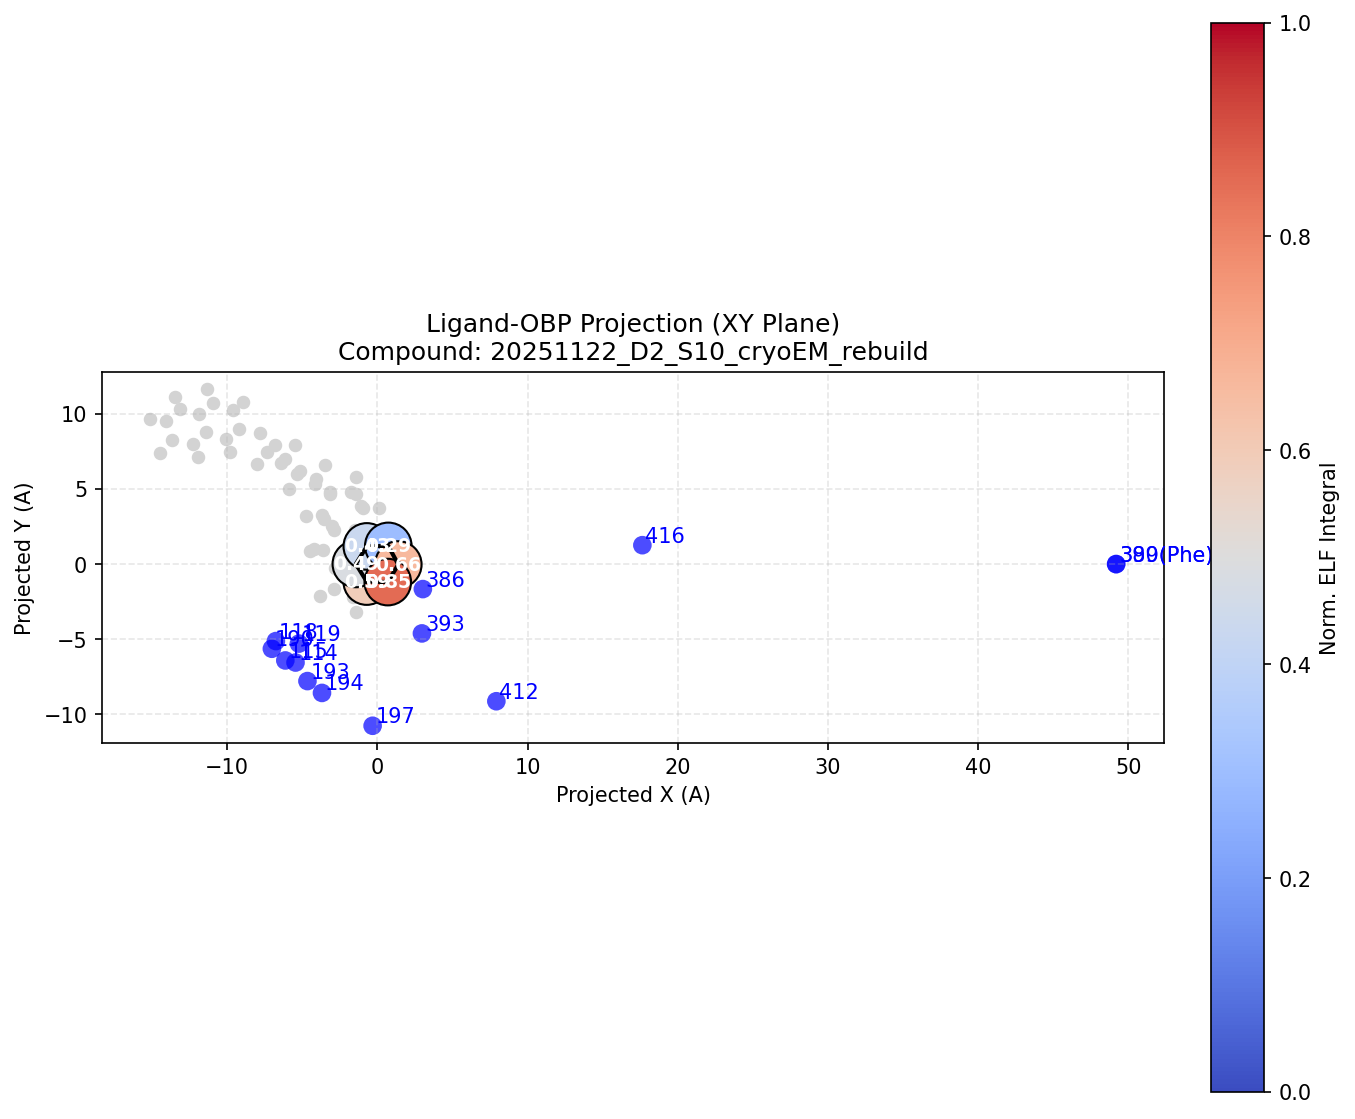

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG (ID 1035) with 61 atoms
     [Match] Norm ELF: 0.29-0.85
  -> Saving plot to 20251122_D2_S10_cryoEM_rebuild_gromacs_replicate_1_projection.png


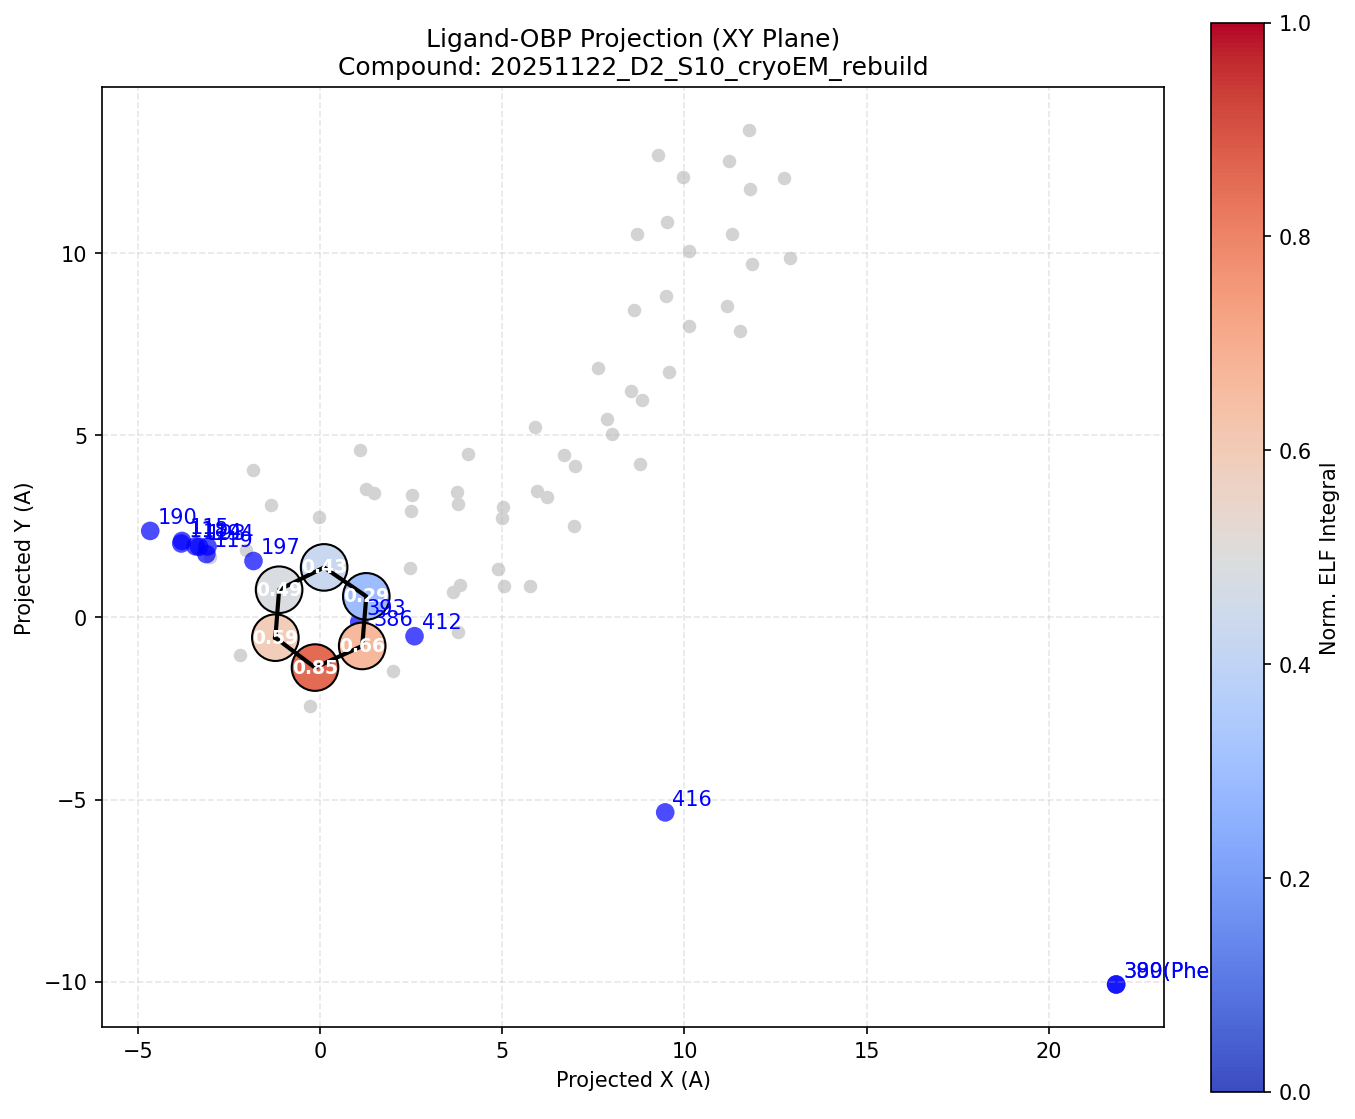

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG (ID 1035) with 61 atoms
     [Match] Norm ELF: 0.29-0.85
  -> Saving plot to 20251122_D2_S10_cryoEM_rebuild_gromacs_replicate_3_projection.png


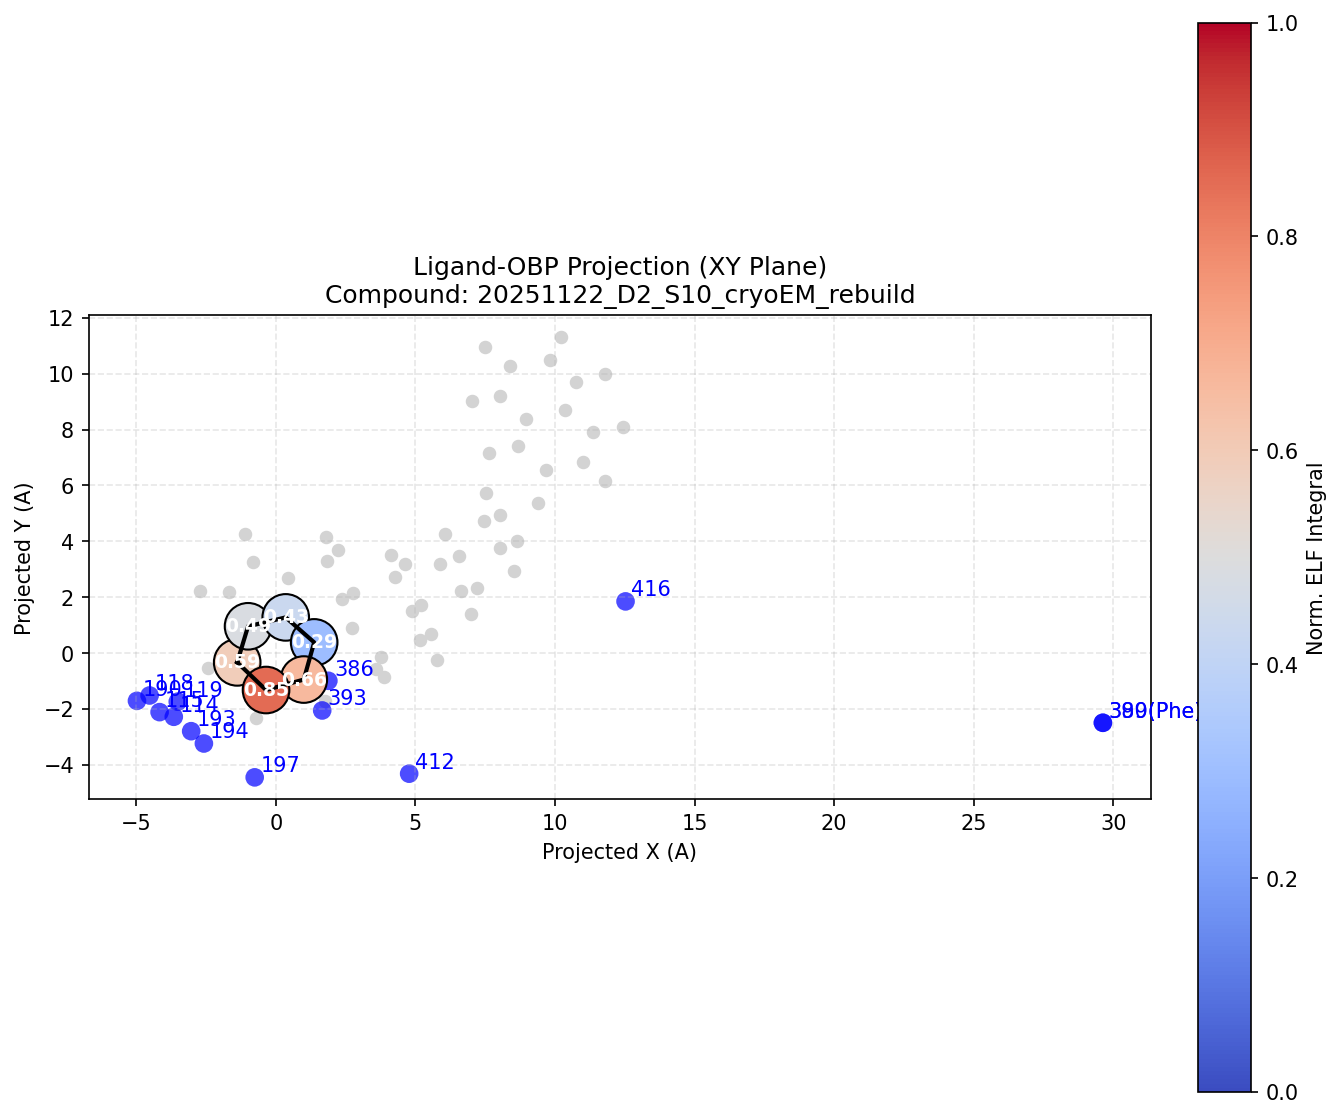

  -> Saved 20251122_D2_S10_cryoEM_rebuild_analysis.csv

Analyzing: 20251115_D2_ARI_cryoEM_rebuild (3 replicates)
  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG (ID 1034) with 60 atoms
     [Match] Norm ELF: 0.47-0.99
  -> Saving plot to 20251115_D2_ARI_cryoEM_rebuild_gromacs_replicate_2_projection.png


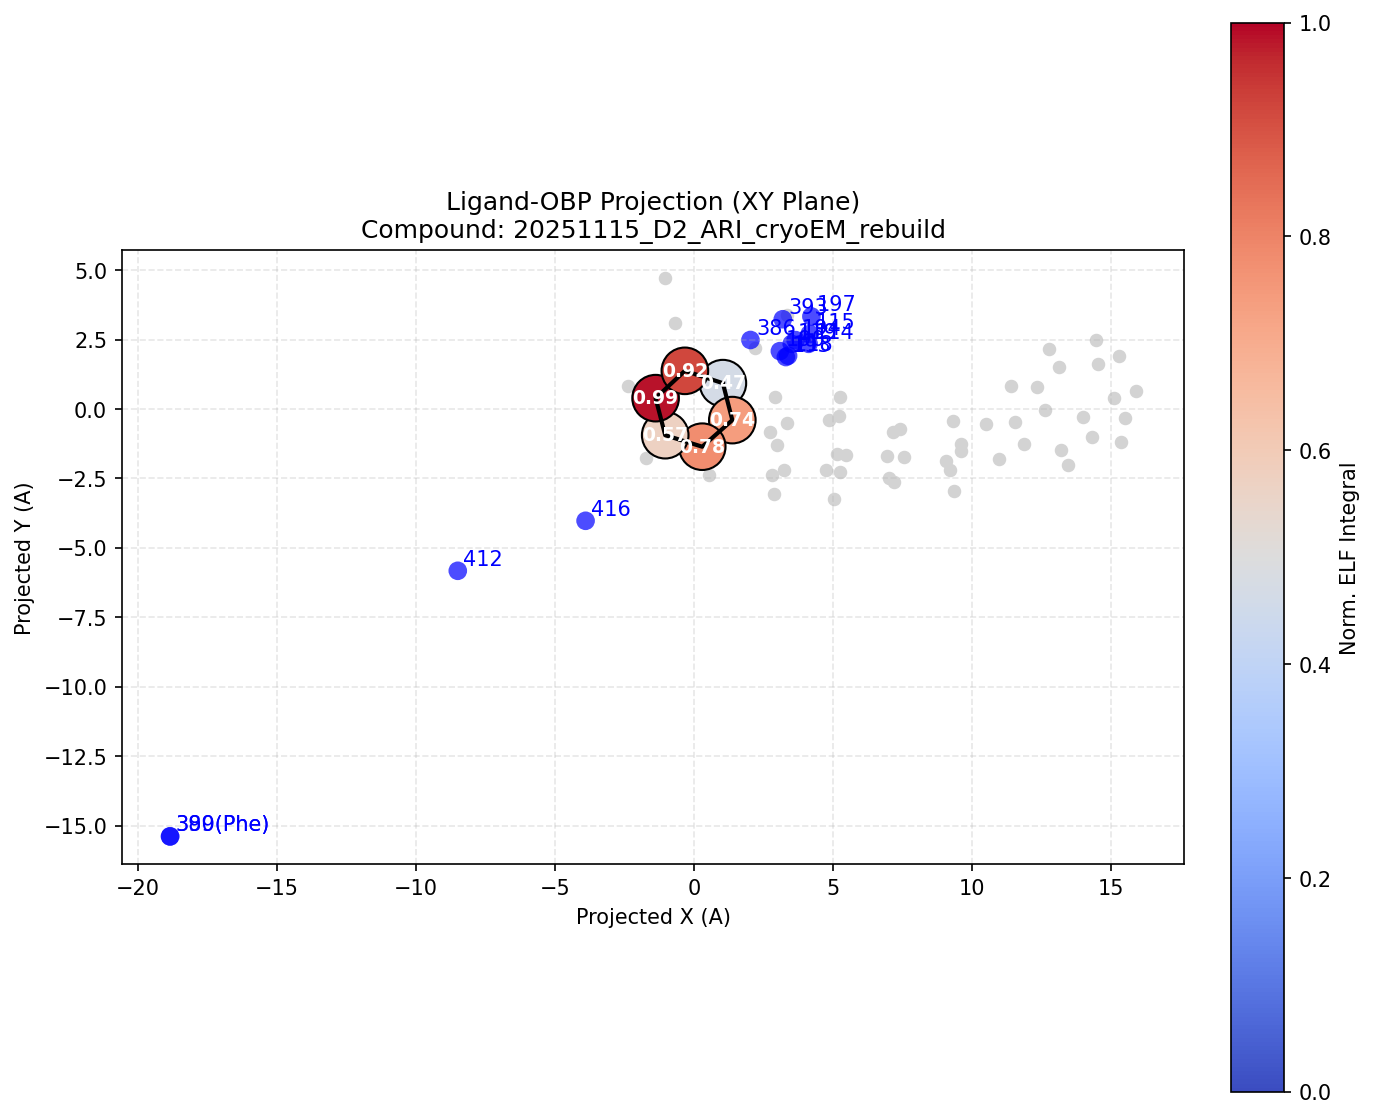

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG (ID 1034) with 60 atoms
     [Match] Norm ELF: 0.47-0.99
  -> Saving plot to 20251115_D2_ARI_cryoEM_rebuild_gromacs_replicate_1_projection.png


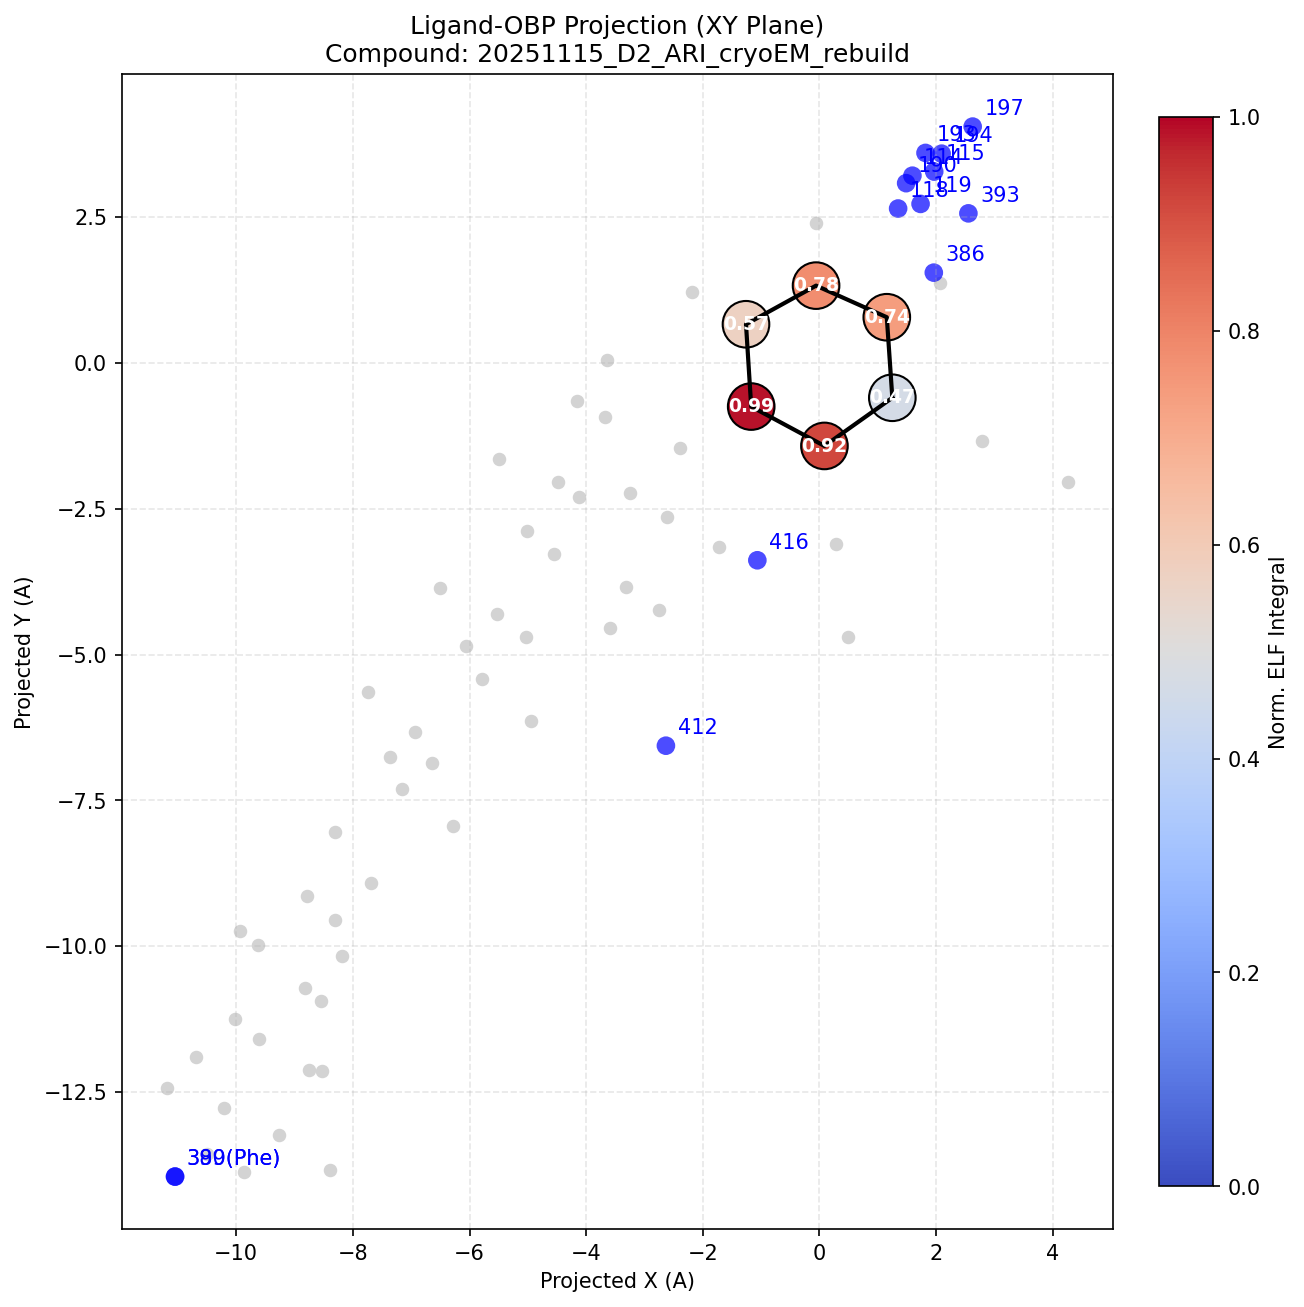

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG (ID 1034) with 60 atoms
     [Match] Norm ELF: 0.47-0.99
  -> Saving plot to 20251115_D2_ARI_cryoEM_rebuild_gromacs_replicate_3_projection.png


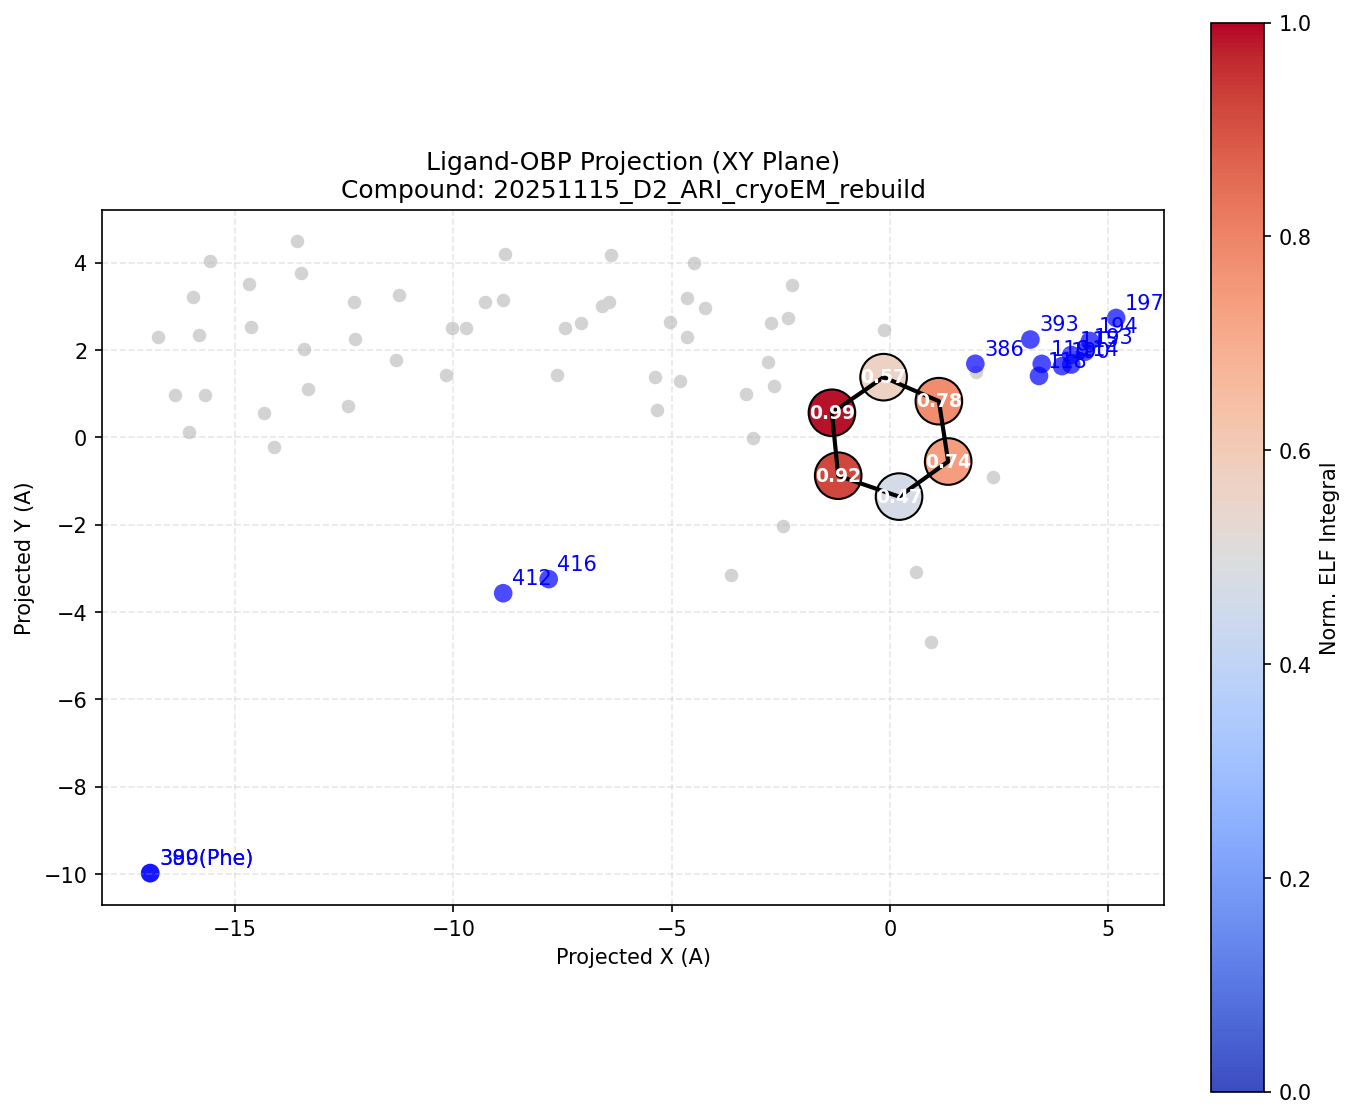

  -> Saved 20251115_D2_ARI_cryoEM_rebuild_analysis.csv

Analyzing: 20251130_D2_ROT_cryoEM_rebuild (3 replicates)
  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: R5F (ID 1036) with 48 atoms
     [Match] Norm ELF: 0.62-0.81
  -> Saving plot to 20251130_D2_ROT_cryoEM_rebuild_gromacs_replicate_2_projection.png


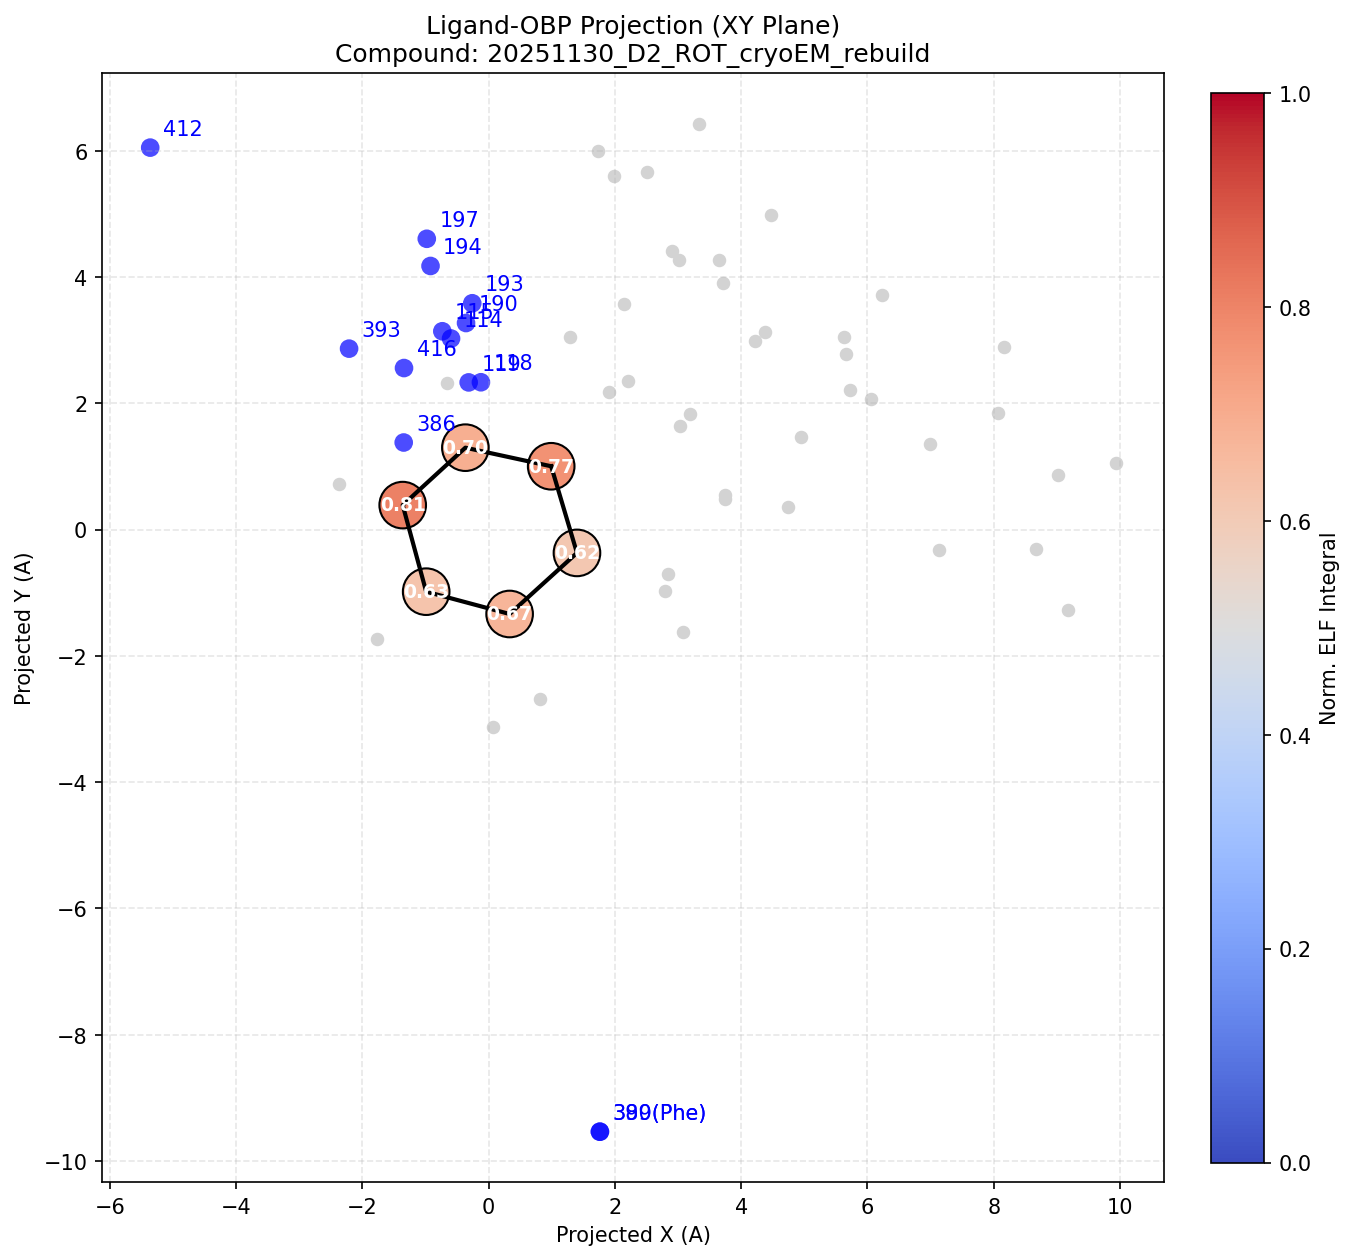

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: R5F (ID 1036) with 48 atoms
     [Match] Norm ELF: 0.62-0.81
  -> Saving plot to 20251130_D2_ROT_cryoEM_rebuild_gromacs_replicate_1_projection.png


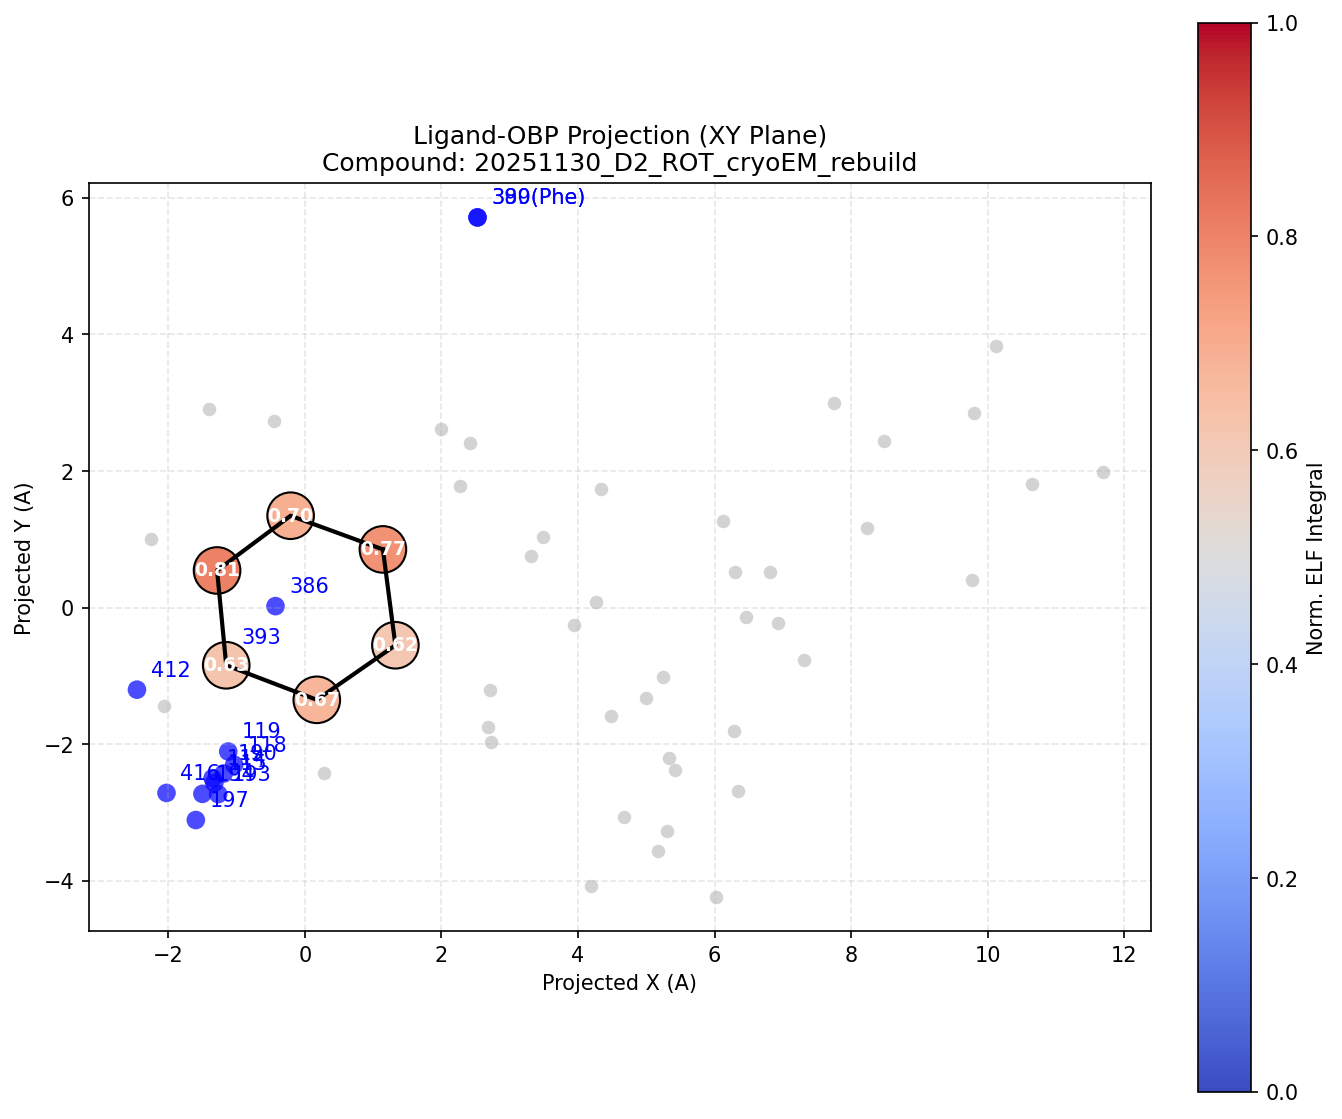

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: R5F (ID 1036) with 48 atoms
     [Match] Norm ELF: 0.62-0.81
  -> Saving plot to 20251130_D2_ROT_cryoEM_rebuild_gromacs_replicate_3_projection.png


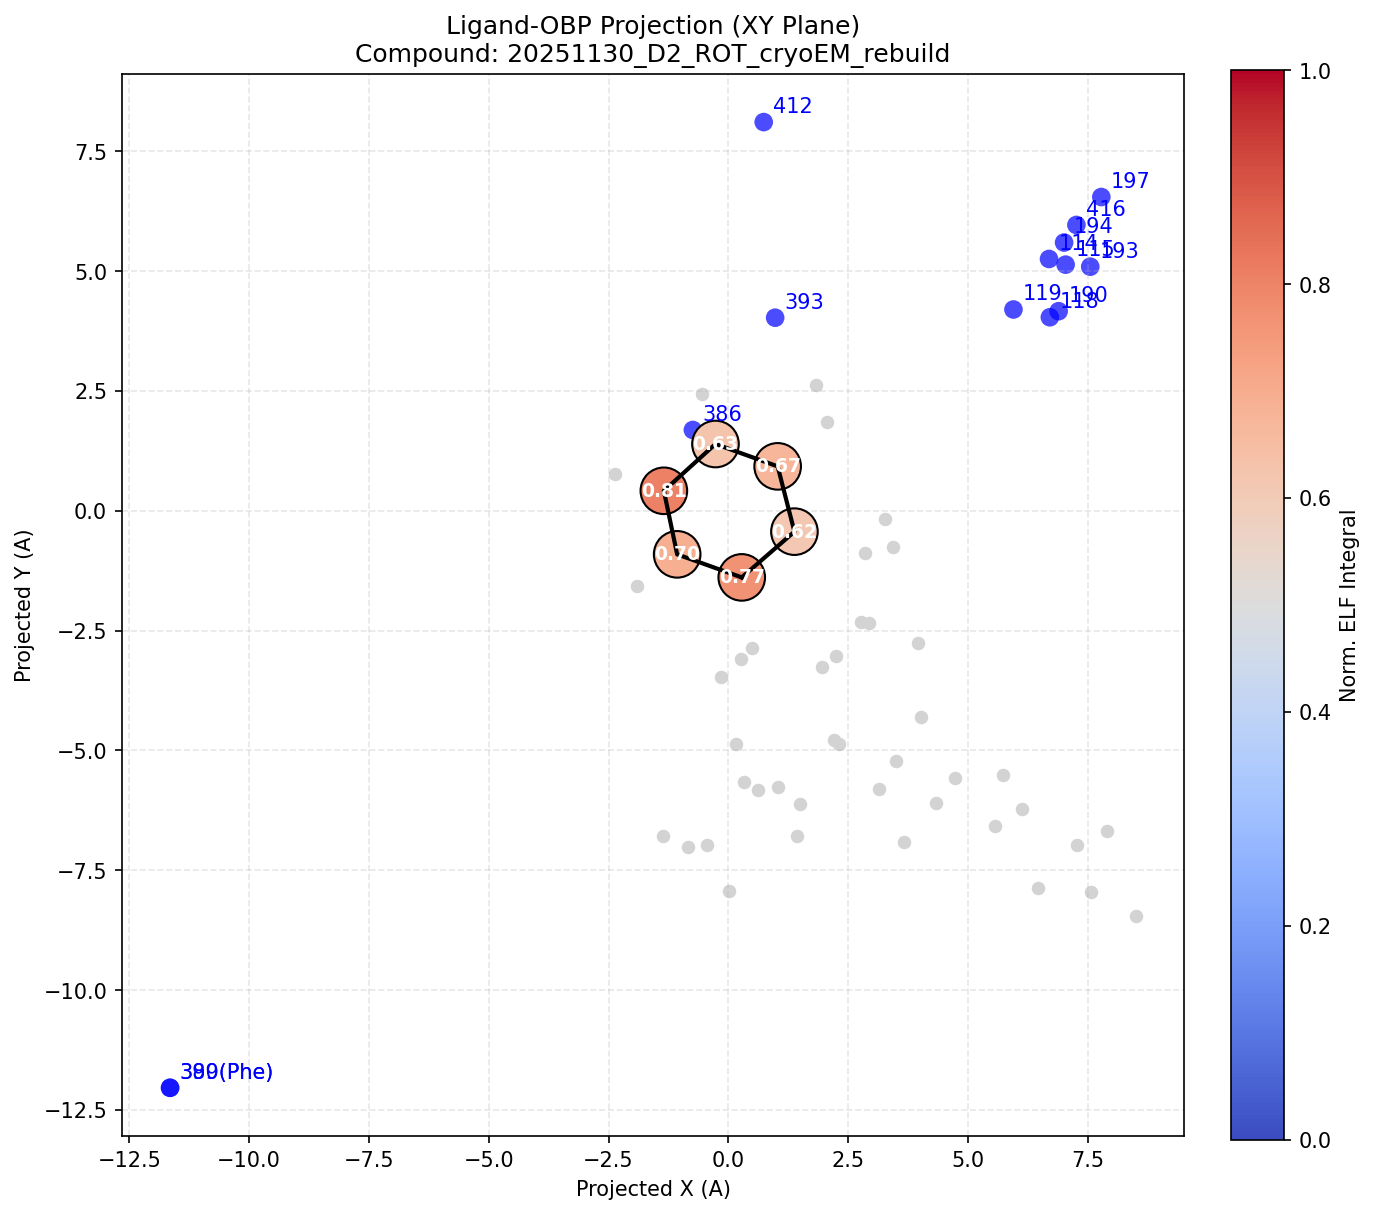

  -> Saved 20251130_D2_ROT_cryoEM_rebuild_analysis.csv

Analyzing: 20251202_D2_S84_boltz (3 replicates)
  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1022) with 60 atoms
     [Match] Norm ELF: 0.65-1.10
  -> Saving plot to 20251202_D2_S84_boltz_gromacs_replicate_2_projection.png


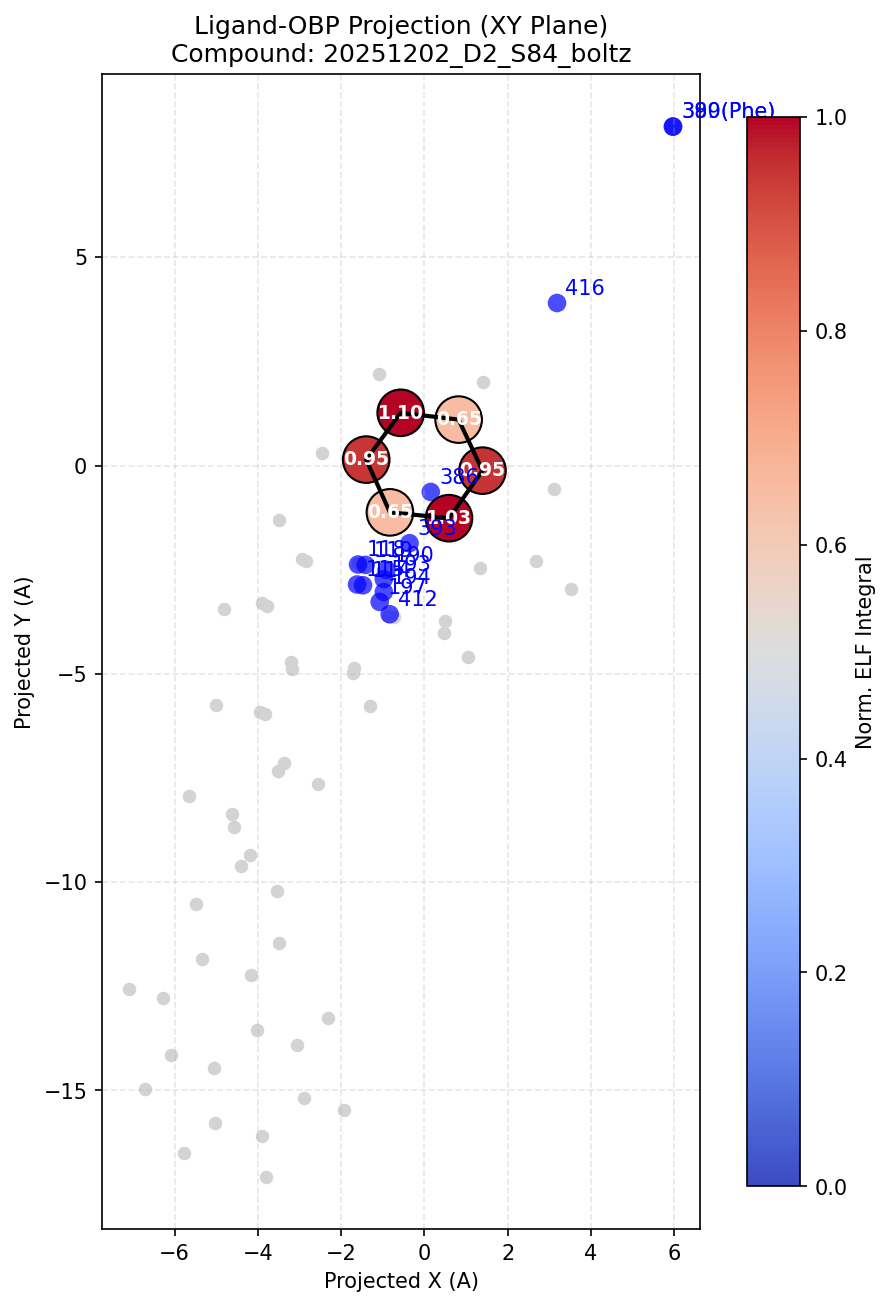

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1022) with 60 atoms
     [Match] Norm ELF: 0.65-1.10
  -> Saving plot to 20251202_D2_S84_boltz_gromacs_replicate_1_projection.png


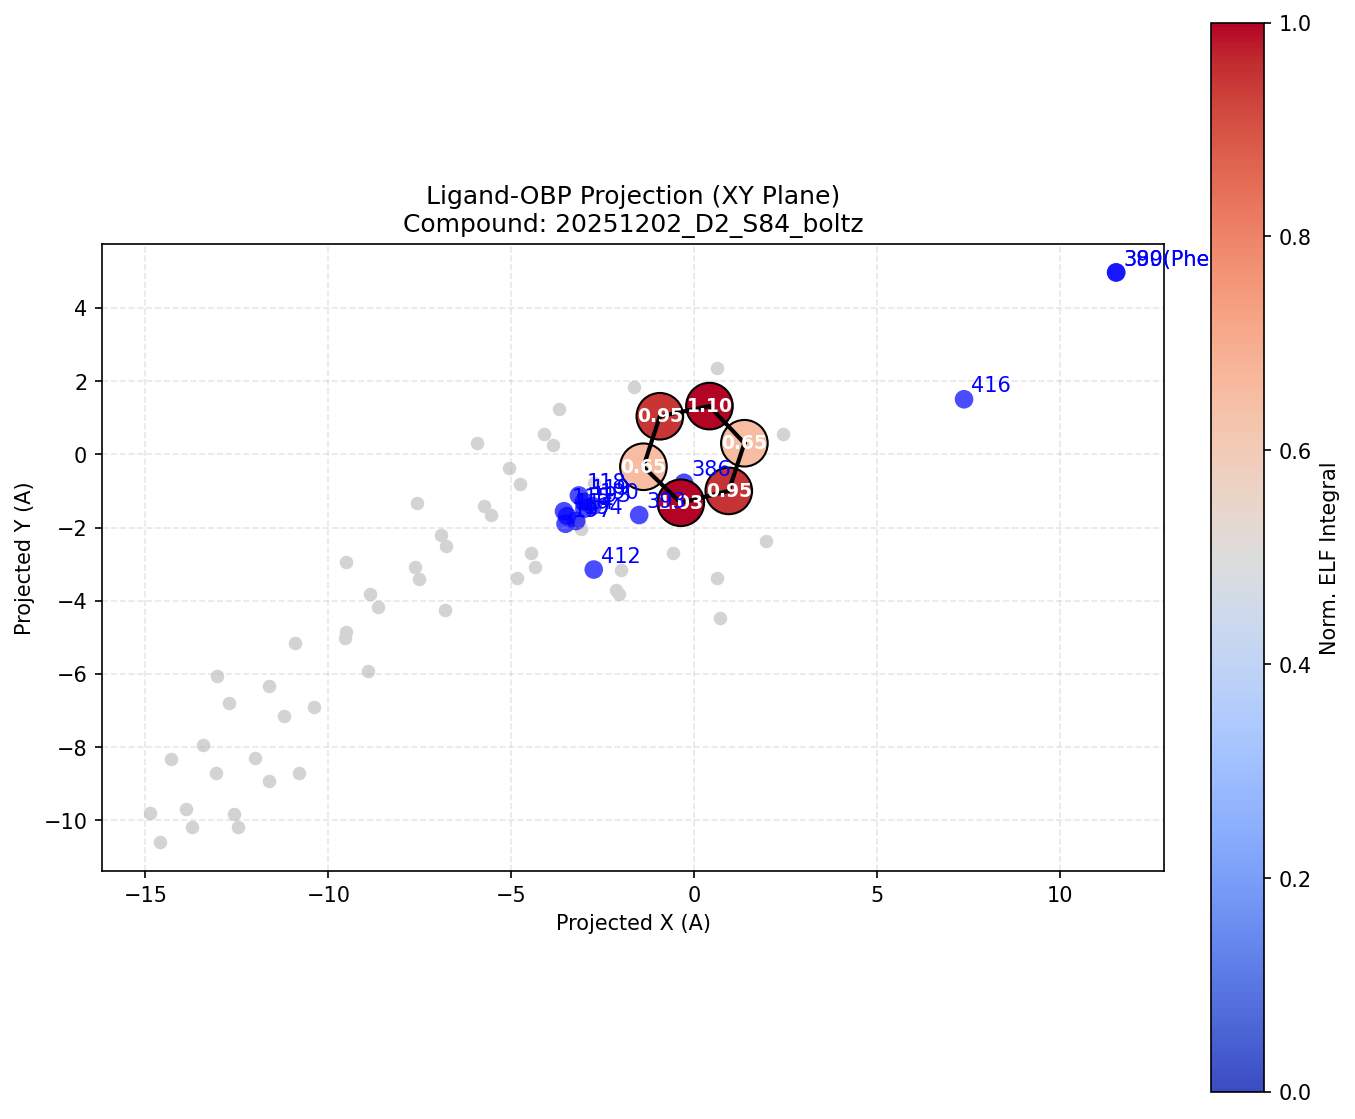

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1022) with 60 atoms
     [Match] Norm ELF: 0.65-1.10
  -> Saving plot to 20251202_D2_S84_boltz_gromacs_replicate_3_projection.png


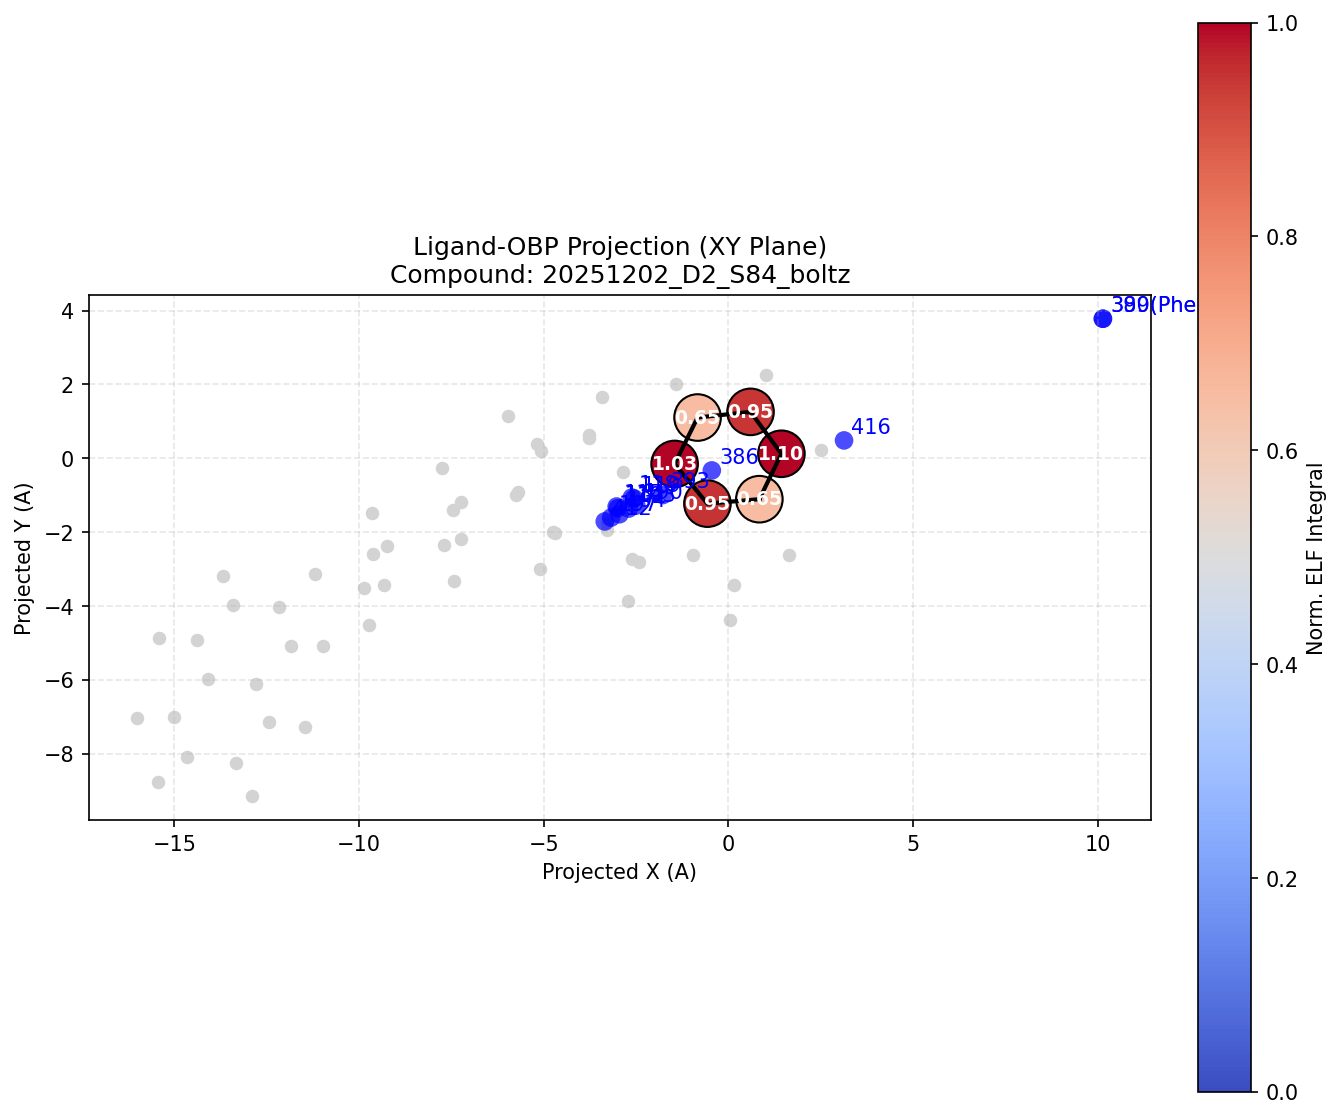

  -> Saved 20251202_D2_S84_boltz_analysis.csv

Analyzing: 20251115_D2_Dopa_cryoEM_rebuild (3 replicates)
  Processing 4 files as one continuous replicate...
     [Info] Identified Ligand: LDP (ID 1027) with 23 atoms
     [Match] Norm ELF: 0.46-1.00
  -> Saving plot to 20251115_D2_Dopa_cryoEM_rebuild_gromacs_replicate_2_projection.png


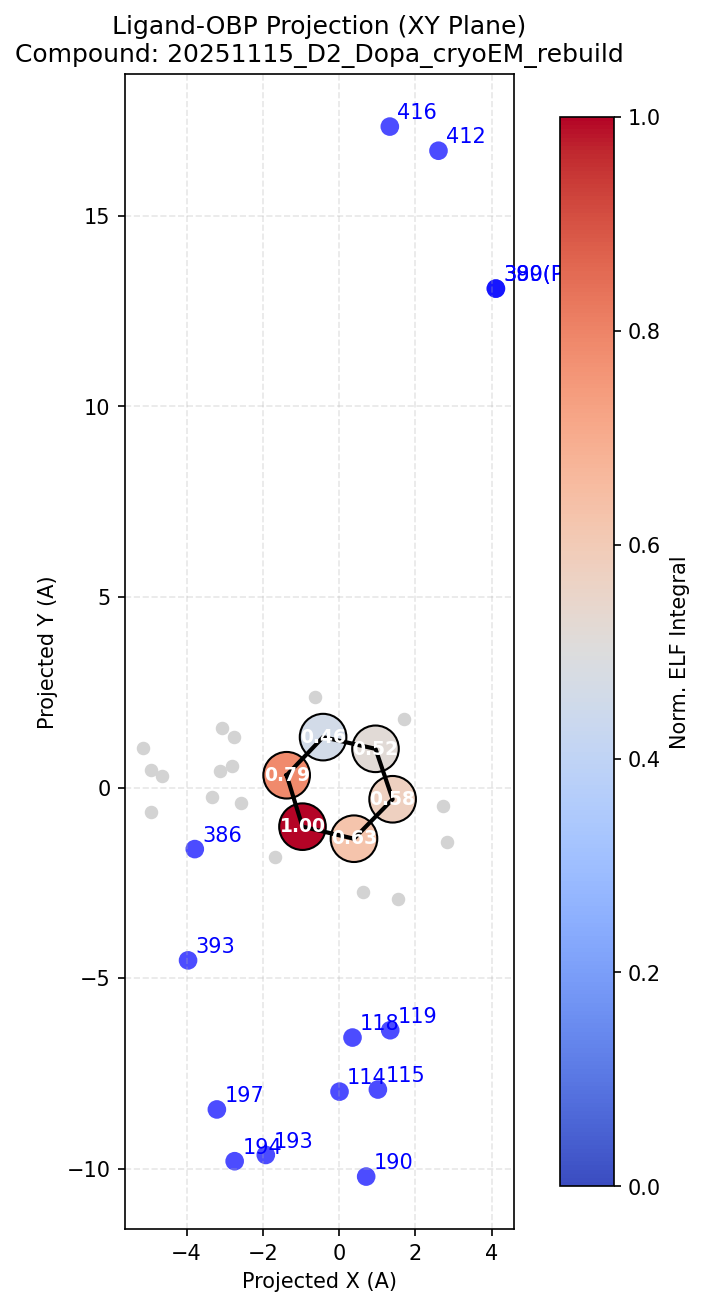

  Processing 4 files as one continuous replicate...
     [Info] Identified Ligand: LDP (ID 1027) with 23 atoms
     [Match] Norm ELF: 0.46-1.00
  -> Saving plot to 20251115_D2_Dopa_cryoEM_rebuild_gromacs_replicate_1_projection.png


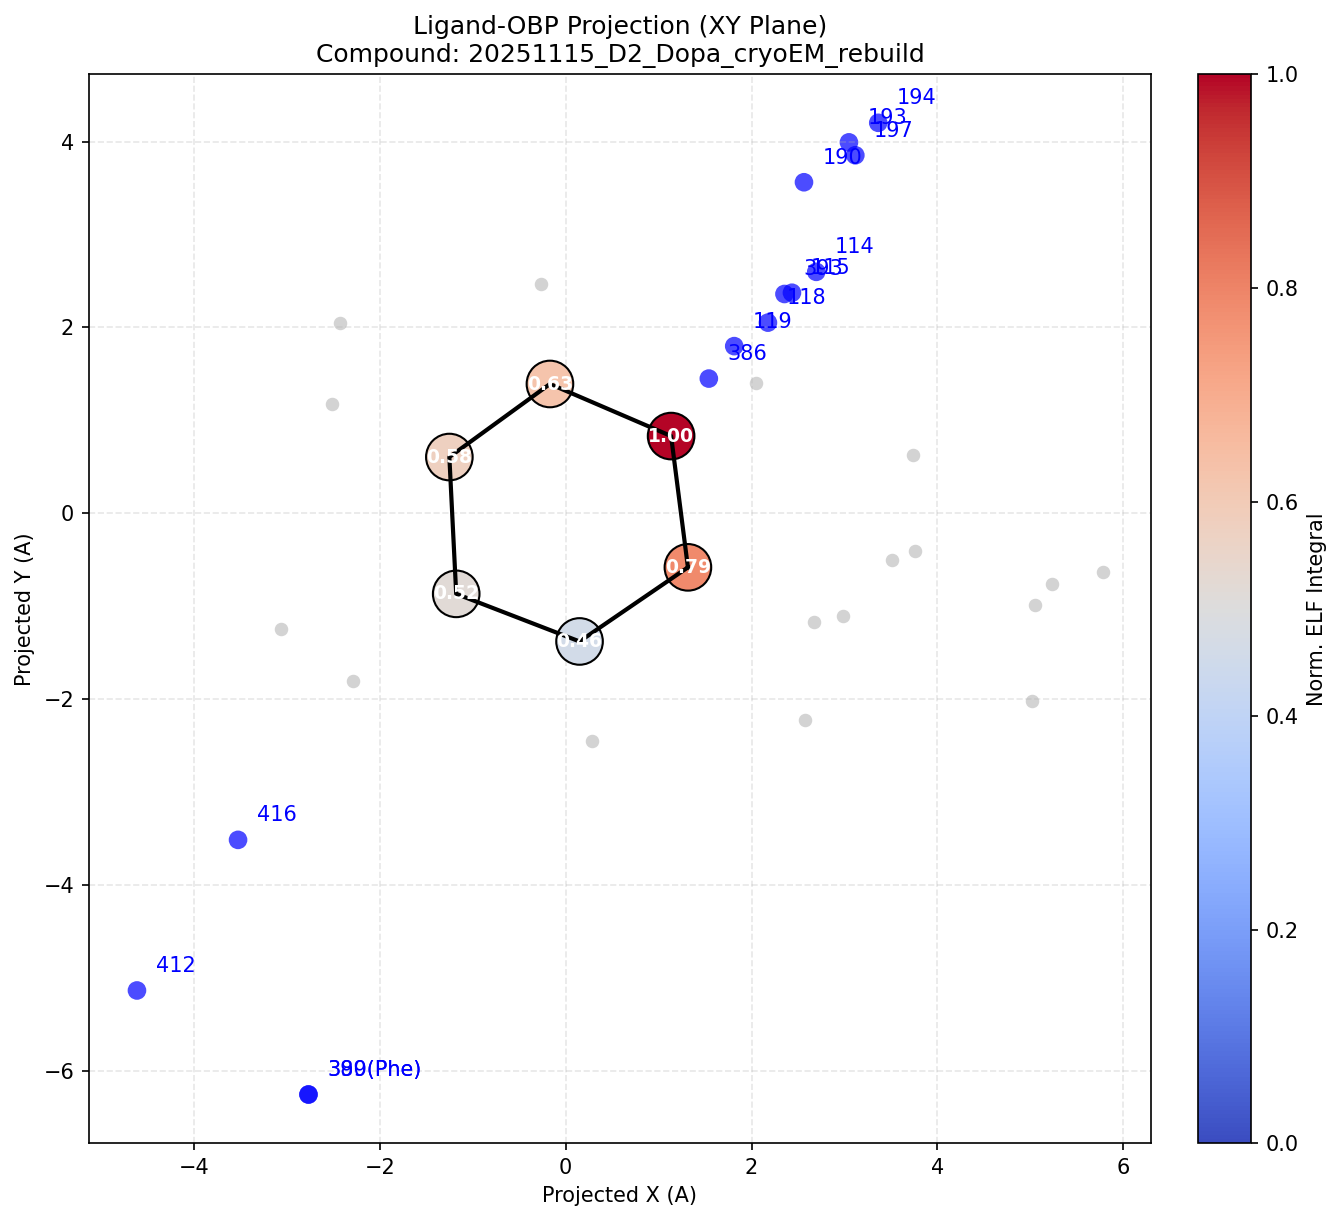

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LDP (ID 1027) with 23 atoms
     [Match] Norm ELF: 0.46-1.00
  -> Saving plot to 20251115_D2_Dopa_cryoEM_rebuild_gromacs_replicate_3_projection.png


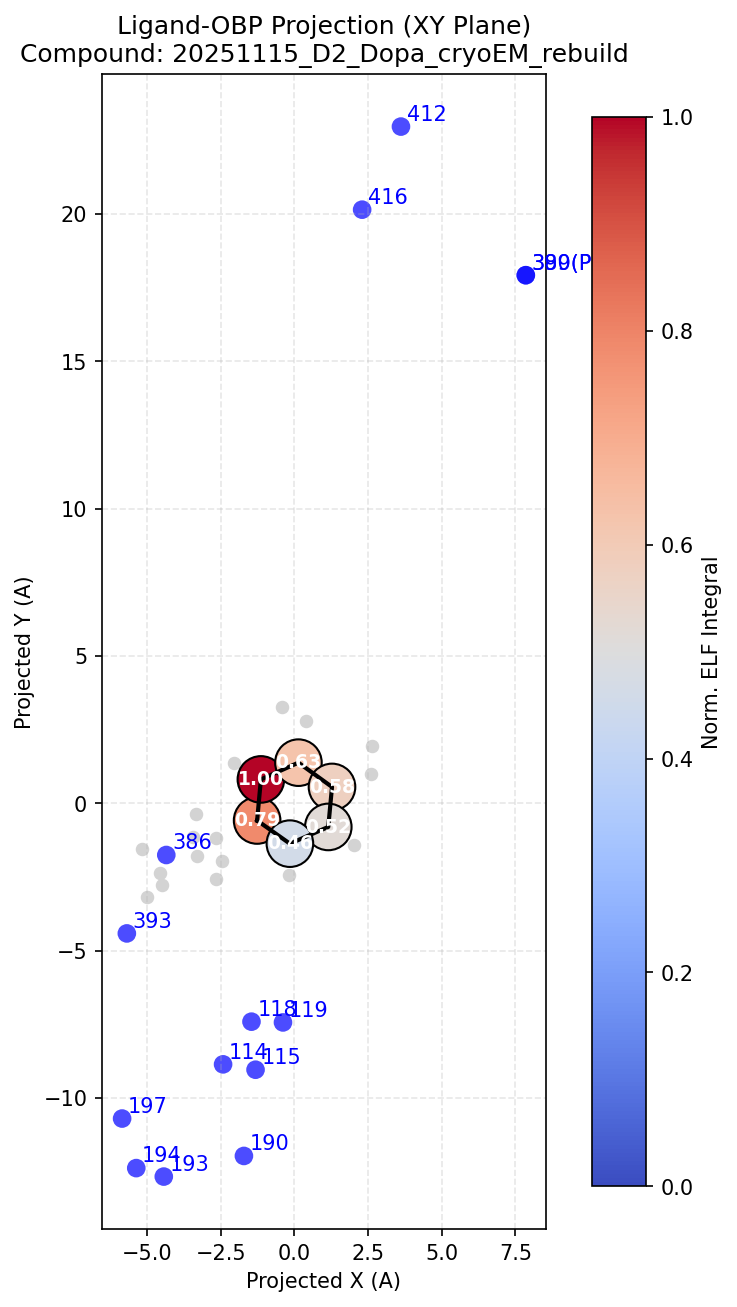

  -> Saved 20251115_D2_Dopa_cryoEM_rebuild_analysis.csv

Analyzing: 20251123_D2_UNC_Boltz (3 replicates)
  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1038) with 59 atoms
     [Match] Norm ELF: 0.49-0.87
  -> Saving plot to 20251123_D2_UNC_Boltz_gromacs_replicate_2_projection.png


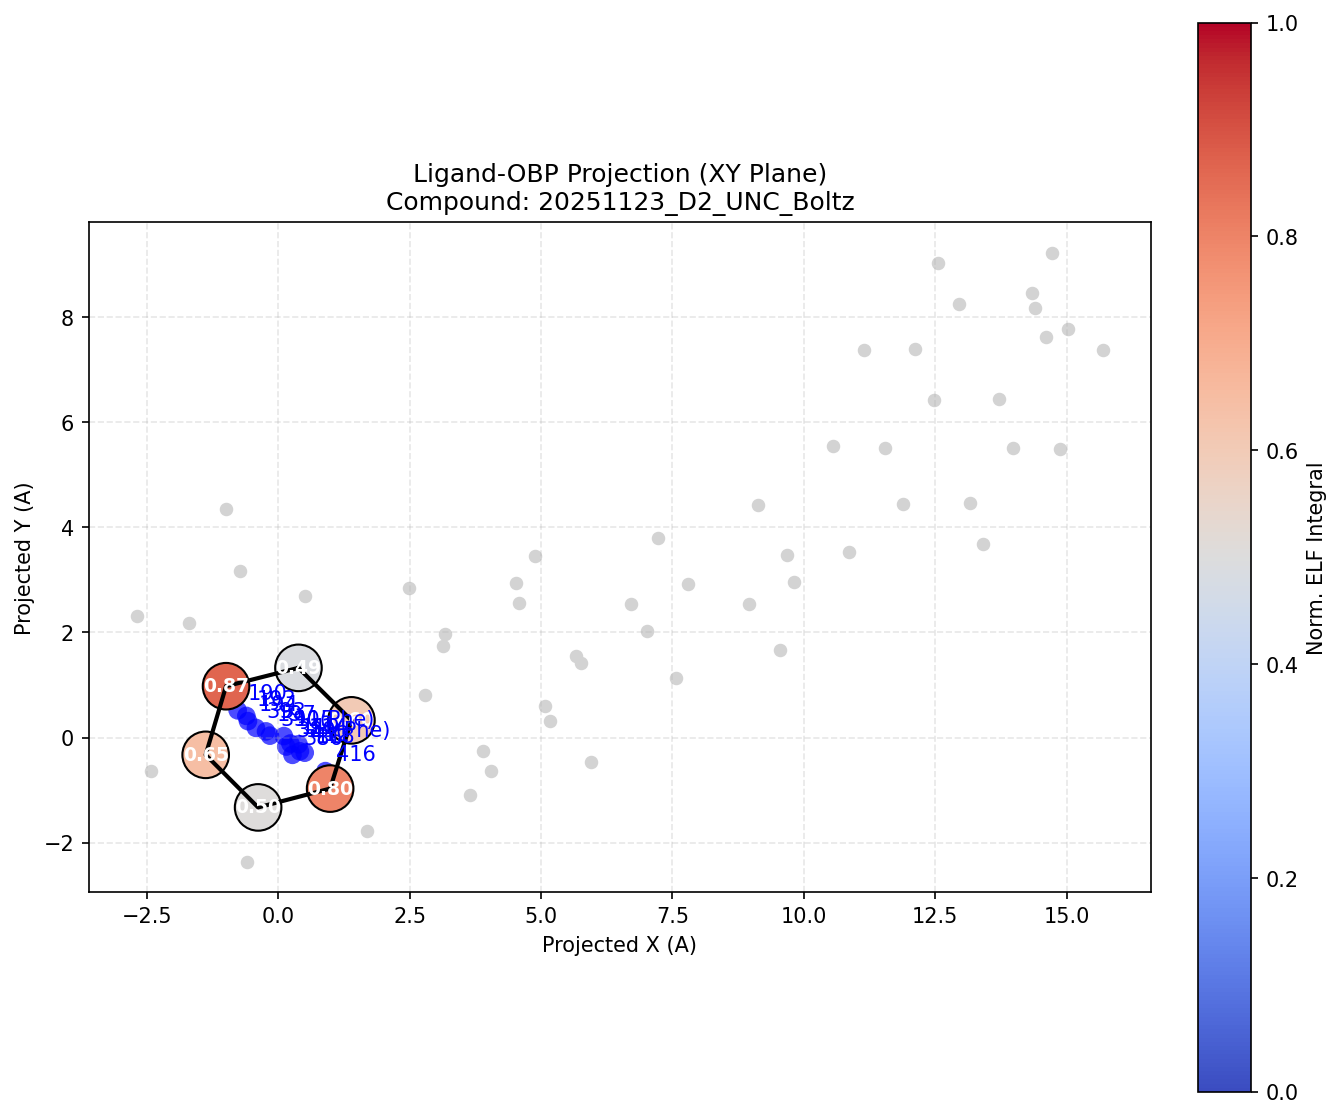

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1038) with 59 atoms
     [Match] Norm ELF: 0.49-0.87
  -> Saving plot to 20251123_D2_UNC_Boltz_gromacs_replicate_1_projection.png


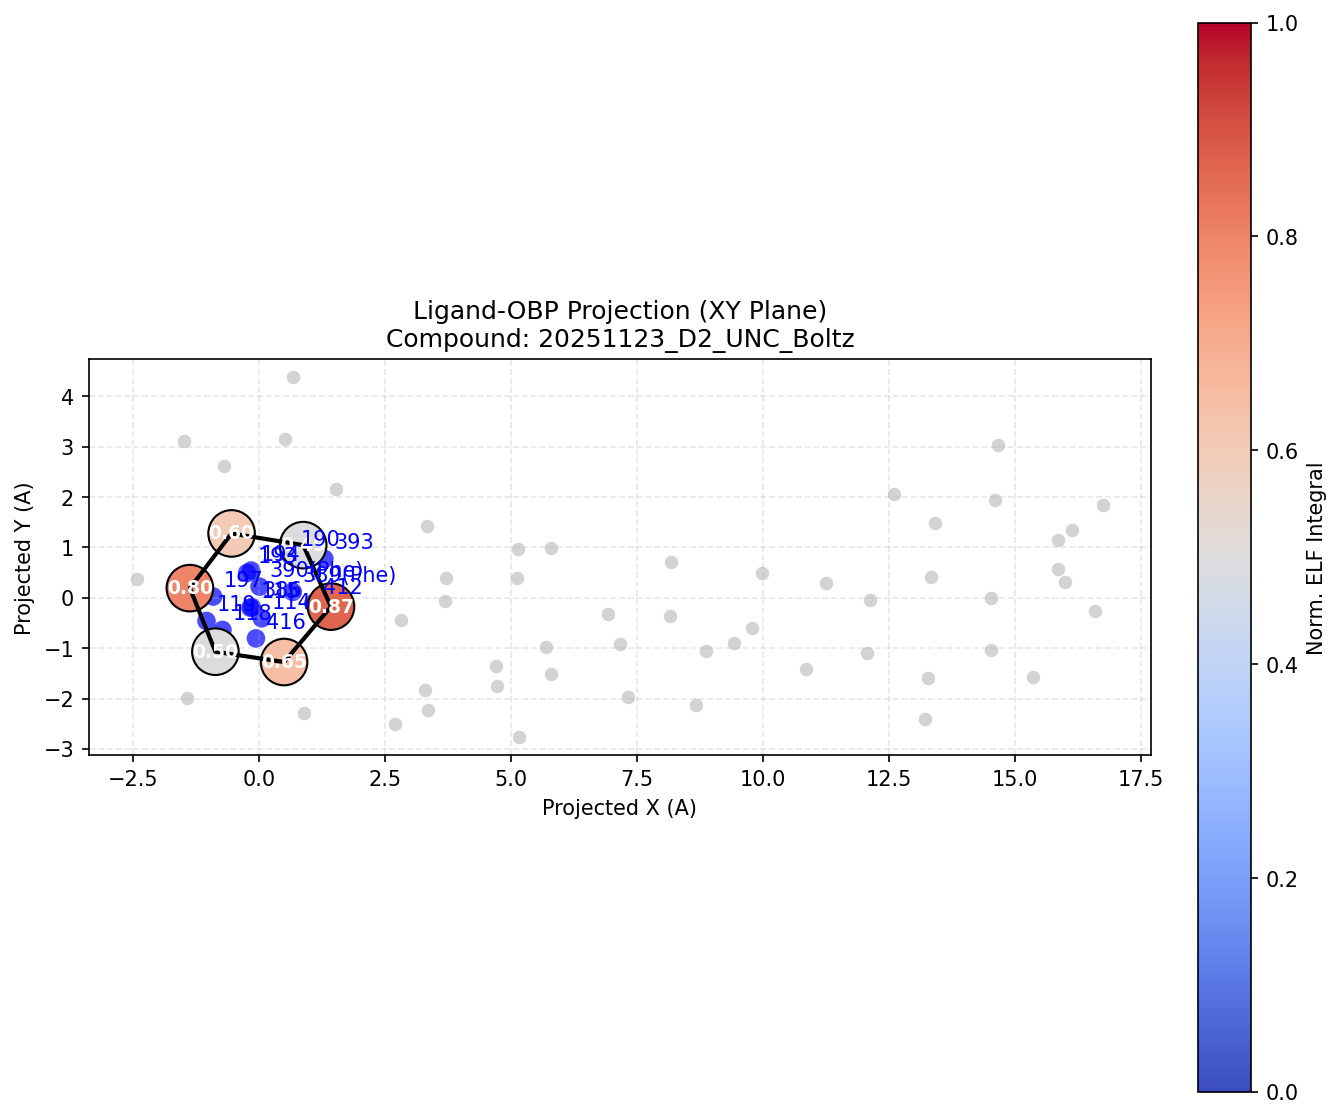

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1038) with 59 atoms
     [Match] Norm ELF: 0.49-0.87
  -> Saving plot to 20251123_D2_UNC_Boltz_gromacs_replicate_3_projection.png


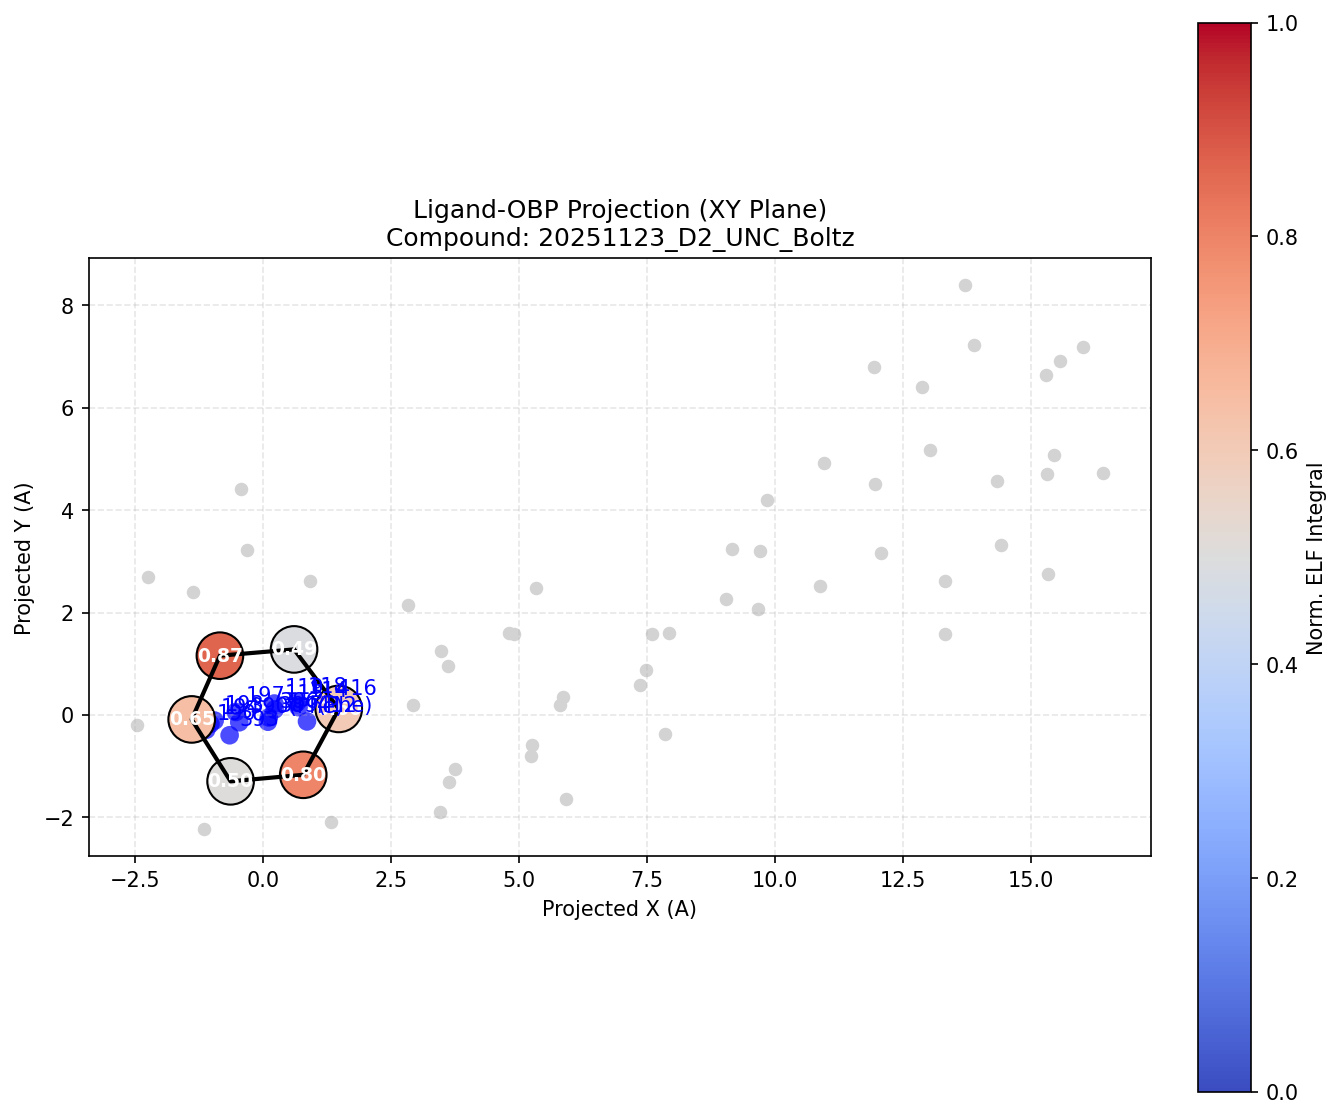

  -> Saved 20251123_D2_UNC_Boltz_analysis.csv

Analyzing: 20251130_D2_BRE_boltz (3 replicates)
  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1022) with 59 atoms
     [Match] Norm ELF: 0.35-0.85
  -> Saving plot to 20251130_D2_BRE_boltz_gromacs_replicate_2_projection.png


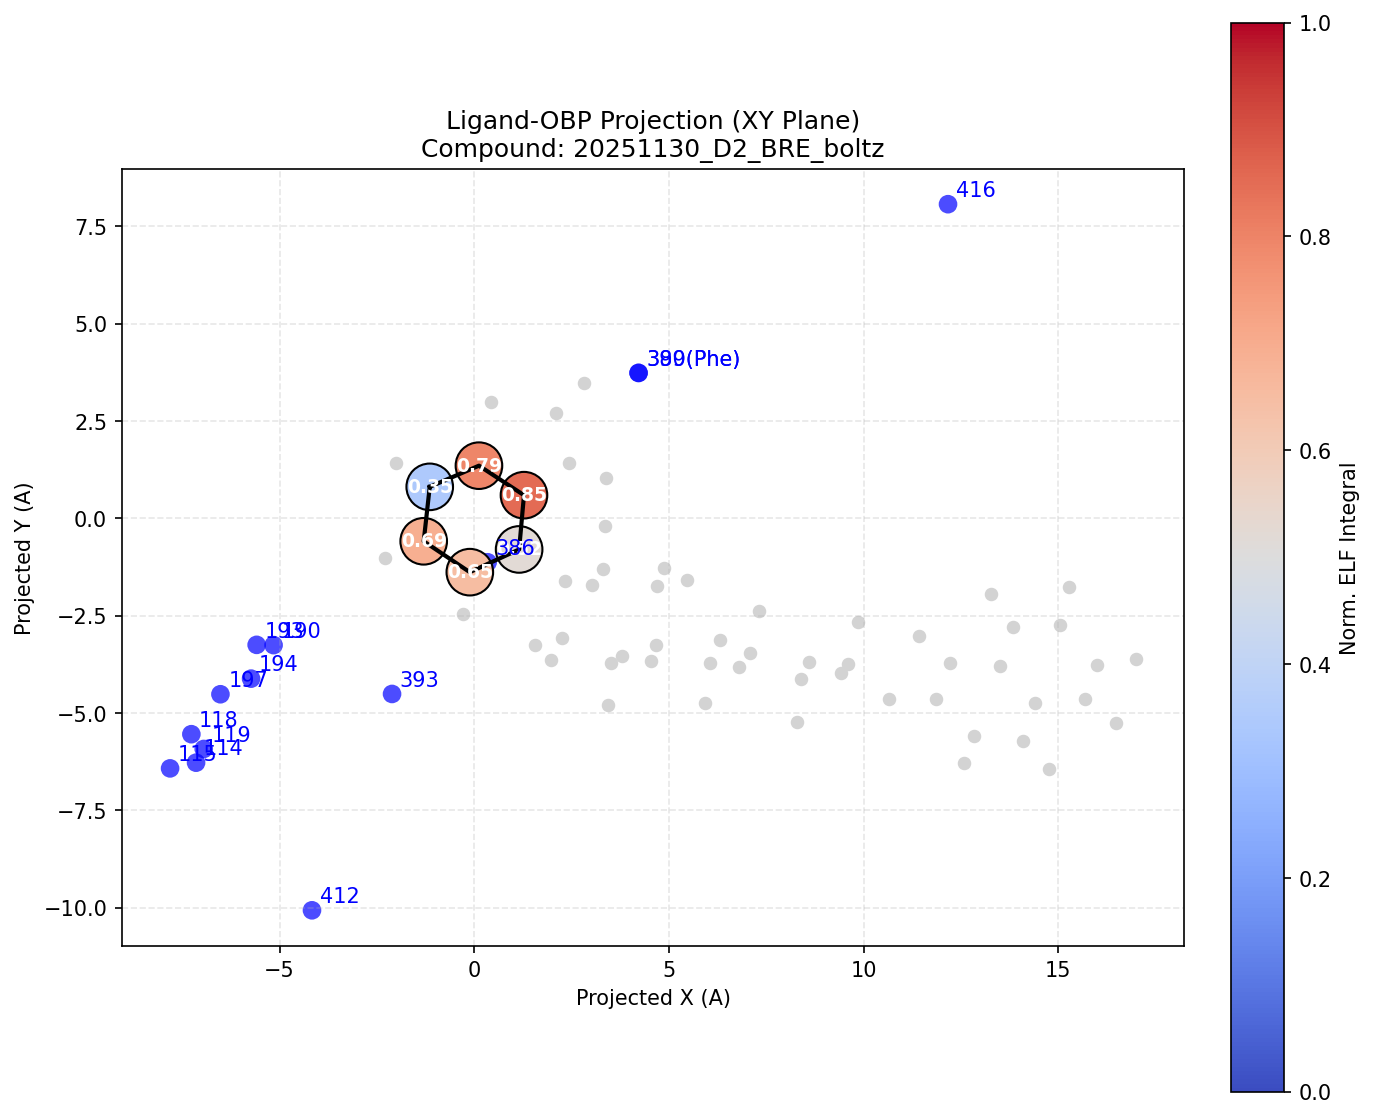

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1022) with 59 atoms
     [Match] Norm ELF: 0.35-0.85
  -> Saving plot to 20251130_D2_BRE_boltz_gromacs_replicate_1_projection.png


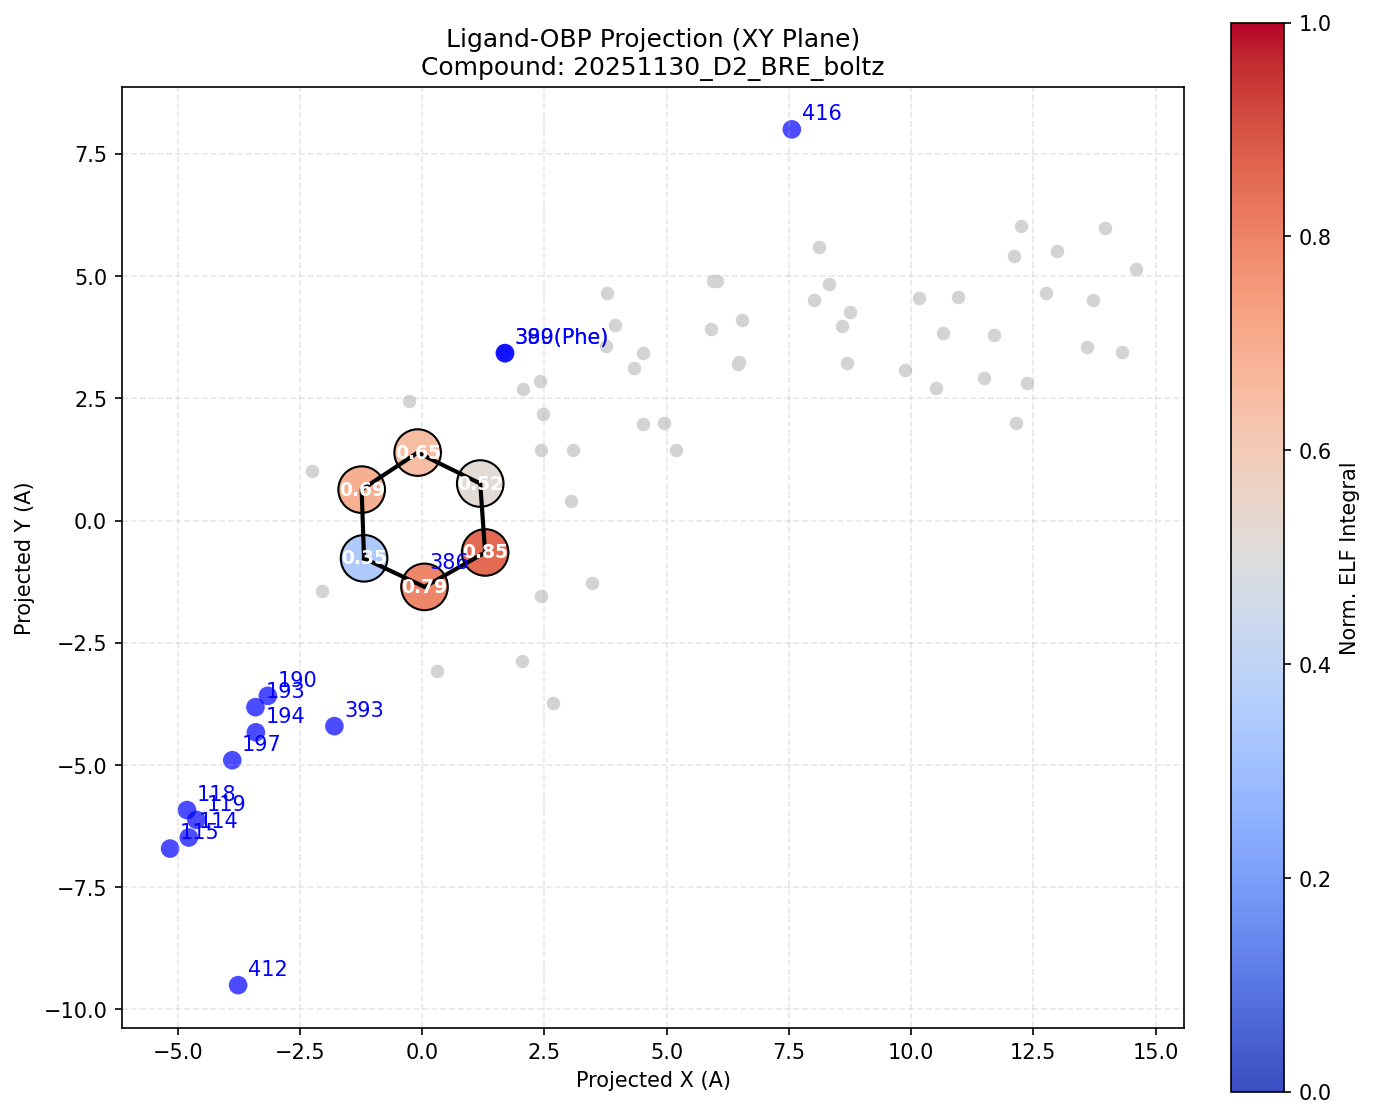

  Processing 3 files as one continuous replicate...
     [Info] Identified Ligand: LIG1 (ID 1022) with 59 atoms
     [Match] Norm ELF: 0.35-0.85
  -> Saving plot to 20251130_D2_BRE_boltz_gromacs_replicate_3_projection.png


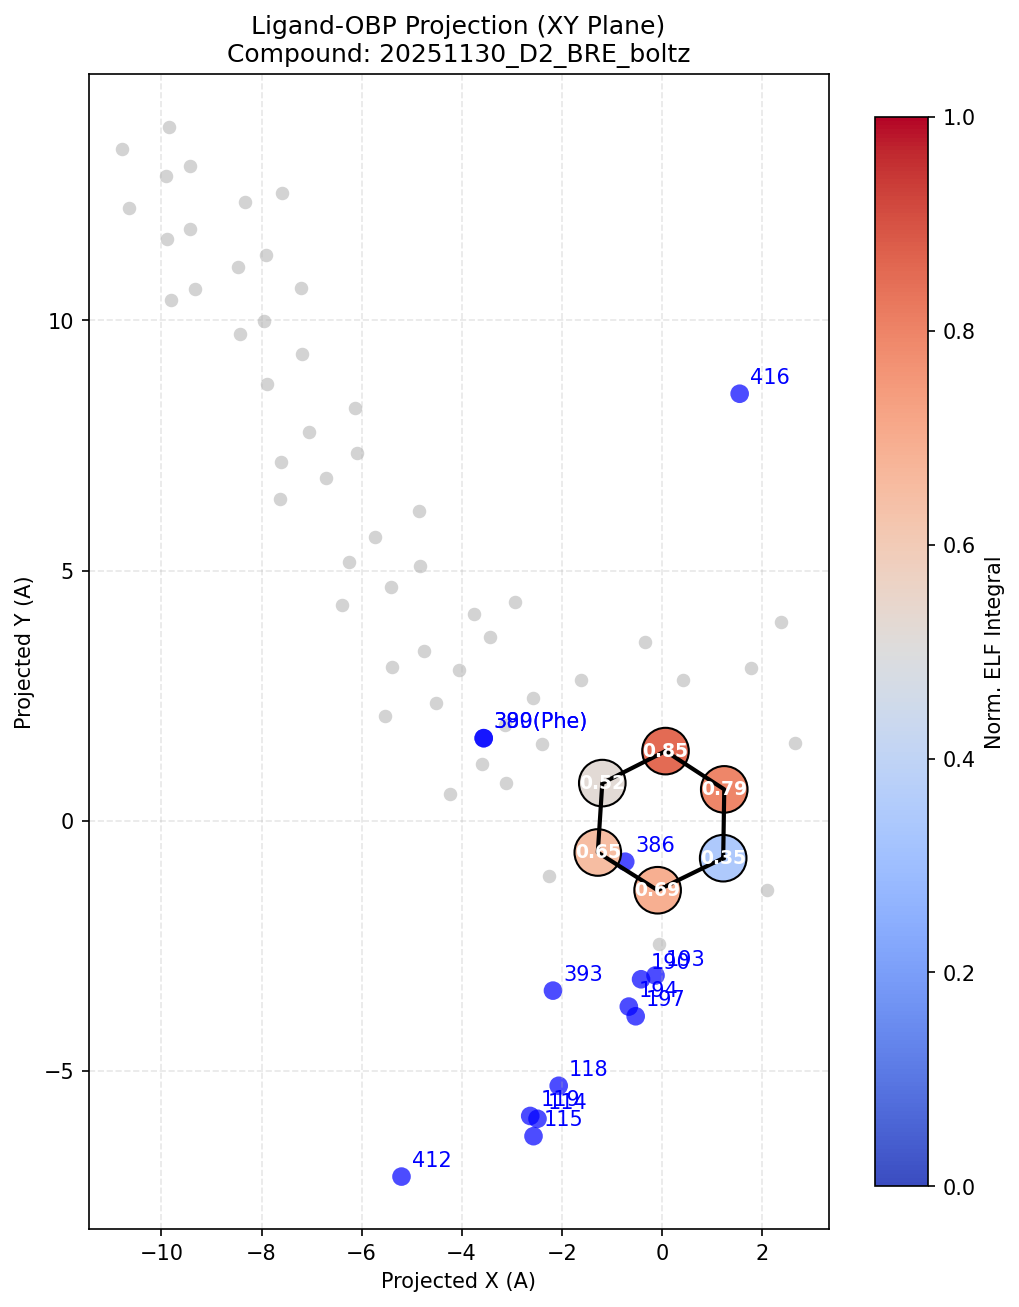

  -> Saved 20251130_D2_BRE_boltz_analysis.csv

Done! All analyses completed.


In [7]:
# Cell 6: Run Analysis

# 1. 扫描全局最大值
root_dir = "." # 你的数据根目录
GLOBAL_DOPA_MAX_INTEGRAL = get_dopa_max_integral(root_dir)
if GLOBAL_DOPA_MAX_INTEGRAL == 0: GLOBAL_DOPA_MAX_INTEGRAL = 1.0

print(f"\n>>> Processing Trajectories... (Dopa Max = {GLOBAL_DOPA_MAX_INTEGRAL:.2f})")

for c_dir in glob.glob(os.path.join(root_dir, "*")):
    if not os.path.isdir(c_dir): continue
    # 忽略非化合物文件夹 (比如 __pycache__)
    if "run_analysis" in c_dir or ".ipynb_checkpoints" in c_dir: continue
    
    cid = os.path.basename(c_dir)
    cubes = glob.glob(os.path.join(c_dir, "*.cub"))
    if not cubes: continue
    cube_file = cubes[0]
    
    ref_pdb = None
    base = os.path.splitext(os.path.basename(cube_file))[0]
    pot = os.path.join(c_dir, f"{base}.pdb")
    if os.path.exists(pot) and get_ref_data_from_pdb(pot)[0] is not None: ref_pdb = pot
    if not ref_pdb:
        for p in glob.glob(os.path.join(c_dir, "*.pdb")):
            if "step7" not in p and "topol" not in p:
                if get_ref_data_from_pdb(p)[0] is not None: ref_pdb = p; break
    if not ref_pdb:
        print(f"[Skip] {cid}: No valid small PDB found."); continue

    xtcs = glob.glob(os.path.join(c_dir, "**", "step7_*.xtc"), recursive=True)
    if not xtcs: continue
    
    rep_groups = {}
    for xtc in xtcs:
        d = os.path.dirname(xtc)
        if d not in rep_groups: rep_groups[d] = []
        rep_groups[d].append(xtc)
        
    print(f"\nAnalyzing: {cid} ({len(rep_groups)} replicates)")
    compound_results = []
    
    for rep_dir, file_list in rep_groups.items():
        sorted_files = sorted(file_list)
        base = os.path.splitext(os.path.basename(sorted_files[0]))[0]
        topos = [os.path.join(rep_dir, f"{base}.tpr"), os.path.join(rep_dir, f"{base}.gro"), os.path.join(rep_dir, "step7_production.tpr")]
        topo = next((t for t in topos if os.path.exists(t)), None)
        
        if topo:
            d = process_trajectory(sorted_files, topo, cube_file, ref_pdb, cid)
            if d: compound_results.append(d)
    
    if compound_results:
        df = pd.DataFrame(compound_results)
        out_csv = f"{cid}_analysis.csv"
        df.to_csv(out_csv, index=False)
        print(f"  -> Saved {out_csv}")

print("\nDone! All analyses completed.")